# Power Outage Forecasting — EDA

In [1]:
# Install dependencies (for Colab)
!pip install netCDF4 xarray -q

In [2]:
import os
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

print('All imports successful!')

All imports successful!


## 1. Data Loading & Structure Overview

In [ ]:
DATA_DIR = 'data/'
TRAIN_PATH = os.path.join(DATA_DIR, 'train.nc')

ds = xr.open_dataset(TRAIN_PATH)
print(ds)
print('\n' + '='*60)
print(f'Timestamps:       {len(ds.timestamp)}')
print(f'Locations:        {len(ds.location)}')
print(f'Weather features: {len(ds.feature)}')
print(f'Time range:       {str(ds.timestamp.values[0])[:19]} ~ {str(ds.timestamp.values[-1])[:19]}')

<xarray.Dataset> Size: 159MB
Dimensions:    (location: 83, timestamp: 2161, feature: 109)
Coordinates:
  * location   (location) <U5 2kB '26001' '26003' '26005' ... '26163' '26165'
    state      (location) <U2 664B ...
  * timestamp  (timestamp) datetime64[ns] 17kB 2023-04-01 ... 2023-06-30
  * feature    (feature) object 872B 'SBT113' 'SBT114' 'SBT123' ... 'wz' 'wz_1'
Data variables:
    tracked    (location, timestamp) float64 1MB ...
    out        (location, timestamp) float64 1MB ...
    weather    (location, timestamp, feature) float64 156MB ...
Attributes:
    time_start:  2022-01-01T00:00:00
    time_end:    2022-01-31T23:00:00
    time_now:    2025-07-08T14:59:10

Timestamps:       2161
Locations:        83
Weather features: 109
Time range:       2023-04-01T00:00:00 ~ 2023-06-30T00:00:00


In [4]:
# Extract core data as numpy arrays
out = ds.out.transpose('timestamp', 'location').values.astype(float)         # (T, L)
tracked = ds.tracked.transpose('timestamp', 'location').values.astype(float) # (T, L)
weather = ds.weather.transpose('timestamp', 'location', 'feature').values.astype(float)  # (T, L, F)

timestamps = pd.to_datetime(ds.timestamp.values)
locations = [str(loc) for loc in ds.location.values]
features = [str(f) for f in ds.feature.values]

T, L = out.shape
F = len(features)
print(f'out shape:     {out.shape}  (T={T}, L={L})')
print(f'tracked shape: {tracked.shape}')
print(f'weather shape: {weather.shape}  (T={T}, L={L}, F={F})')
print(f'\nWeather feature list:\n{features}')

out shape:     (2161, 83)  (T=2161, L=83)
tracked shape: (2161, 83)
weather shape: (2161, 83, 109)  (T=2161, L=83, F=109)

Weather feature list:
['SBT113', 'SBT114', 'SBT123', 'SBT124', 'aod', 'bgrun', 'blh', 'cape', 'cape_1', 'cfnsf', 'cfrzr', 'cicep', 'cin', 'cnwat', 'cpofp', 'crain', 'csnow', 'd2m', 'fricv', 'frzr', 'fsr', 'gflux', 'gh', 'gh_1', 'gh_2', 'gh_3', 'gh_4', 'gh_5', 'gh_6', 'gh_7', 'gust', 'hail', 'hail_1', 'hail_2', 'hcc', 'ishf', 'lai', 'layth', 'lcc', 'lftx', 'lftx4', 'lsm', 'ltng', 'max_10si', 'mcc', 'mdens', 'mslma', 'mstav', 'orog', 'pcdb', 'plpl', 'prate', 'pres', 'pres_1', 'pres_2', 'pt', 'pwat', 'r', 'r2', 'r_1', 'refc', 'refd', 'refd_1', 'sde', 'sdlwrf', 'sdswrf', 'sdwe', 'sdwe_1', 'sh2', 'siconc', 'slhtf', 'snowc', 'sp', 'ssrun', 'sulwrf', 'suswrf', 't', 't2m', 'tcc', 'tcc_1', 'tcoli', 'tcolw', 'tp', 'u', 'u10', 'unknown', 'unknown_1', 'unknown_2', 'unknown_3', 'unknown_4', 'unknown_5', 'unknown_6', 'unknown_7', 'unknown_8', 'unknown_9', 'ustm', 'v', 'v10', 'vb

## 2. Outage Distribution Analysis

Shape of the `out` distribution: highly right-skewed. We need a target transformation (e.g., log).

In [26]:
# Basic statistics
out_flat = out.flatten()
out_flat_nonzero = out_flat[out_flat > 0]

print('=== Global Outage Statistics ===')
print(f'Mean:        {np.nanmean(out_flat):.2f}')
print(f'Median:      {np.nanmedian(out_flat):.2f}')
print(f'Std Dev:     {np.nanstd(out_flat):.2f}')
print(f'Min:         {np.nanmin(out_flat):.0f}')
print(f'Max:         {np.nanmax(out_flat):.0f}')
print(f'Skewness:    {stats.skew(out_flat[~np.isnan(out_flat)]):.2f}')
print(f'Kurtosis:    {stats.kurtosis(out_flat[~np.isnan(out_flat)]):.2f}')
print(f'Zero ratio:  {(out_flat == 0).sum() / len(out_flat) * 100:.1f}%')
print(f'\nQuantiles:')
for q in [0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.999]:
    print(f'  {q*100:5.1f}%: {np.nanquantile(out_flat, q):>10.1f}')

=== Global Outage Statistics ===
Mean:        45.25
Median:      0.00
Std Dev:     452.27
Min:         0
Max:         23346
Skewness:    26.37
Kurtosis:    947.23
Zero ratio:  70.5%

Quantiles:
   25.0%:        0.0
   50.0%:        0.0
   75.0%:        1.0
   90.0%:       18.0
   95.0%:      100.0
   99.0%:      933.0
   99.9%:     6215.3


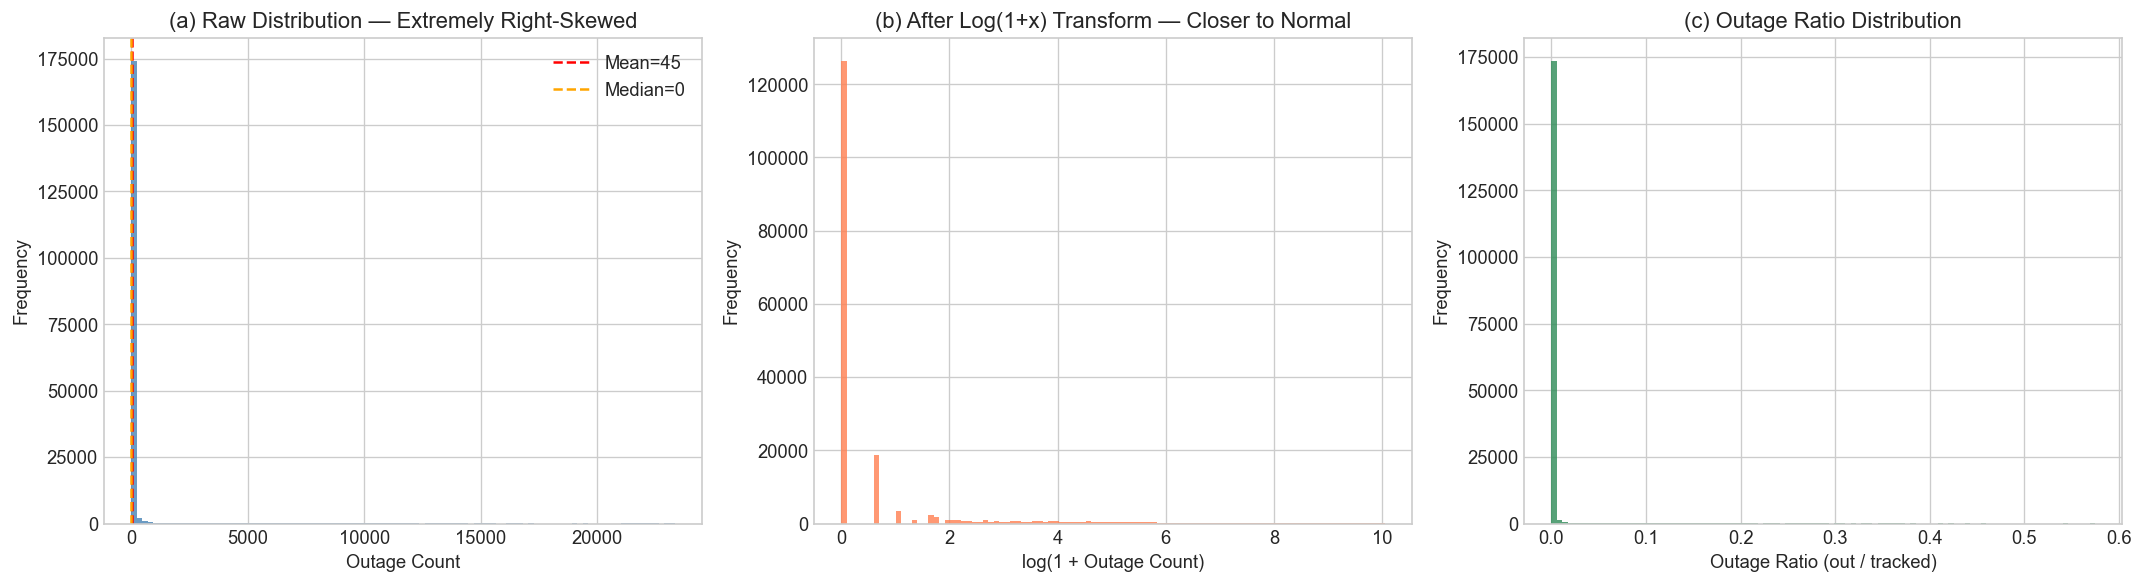

In [27]:
# Outage distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Raw distribution — heavily right-skewed
axes[0].hist(out_flat, bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('Outage Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('(a) Raw Distribution — Extremely Right-Skewed')
axes[0].axvline(np.nanmean(out_flat), color='red', linestyle='--', label=f'Mean={np.nanmean(out_flat):.0f}')
axes[0].axvline(np.nanmedian(out_flat), color='orange', linestyle='--', label=f'Median={np.nanmedian(out_flat):.0f}')
axes[0].legend()

# (b) Log(1+x) transform — closer to normal
out_log = np.log1p(out_flat)
axes[1].hist(out_log, bins=100, color='coral', edgecolor='none', alpha=0.8)
axes[1].set_xlabel('log(1 + Outage Count)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('(b) After Log(1+x) Transform — Closer to Normal')

# (c) Outage ratio (out / tracked)
ratio = (out / tracked).flatten()
ratio = ratio[~np.isnan(ratio) & (ratio < 1)]
axes[2].hist(ratio, bins=100, color='seagreen', edgecolor='none', alpha=0.8)
axes[2].set_xlabel('Outage Ratio (out / tracked)')
axes[2].set_ylabel('Frequency')
axes[2].set_title('(c) Outage Ratio Distribution')

plt.tight_layout()
plt.show()


log(1+x) transform significantly improves distribution shape — recommended as model target.\
Outage ratio (out/tracked) normalizes differences between large and small counties.

## 3. Temporal Patterns

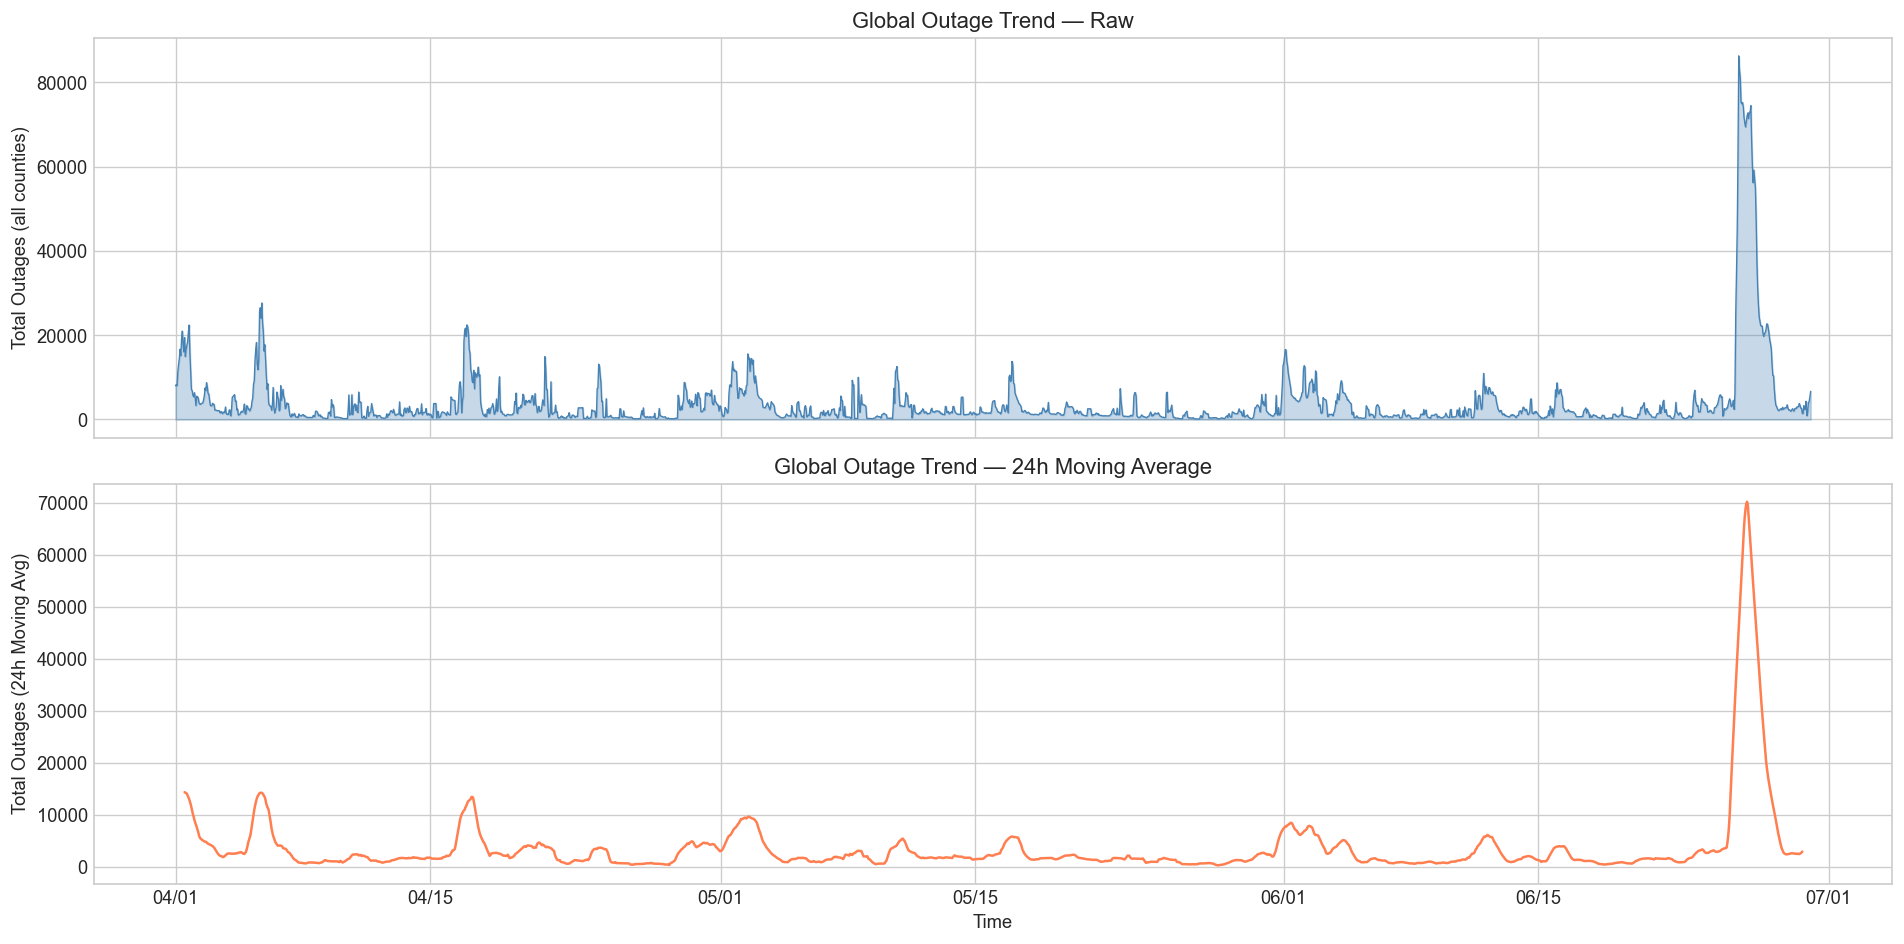


Extreme outage events (>99th percentile = 56608):
Total hours above threshold: 22
Distinct events: ~1
  2023-06-26 00:00


In [7]:
# 3.1 Global outage trend (sum across all counties)
total_outage_per_hour = np.nansum(out, axis=1)  # (T,)

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Raw values
axes[0].plot(timestamps, total_outage_per_hour, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Total Outages (all counties)')
axes[0].set_title('Global Outage Trend — Raw')
axes[0].fill_between(timestamps, total_outage_per_hour, alpha=0.3, color='steelblue')

# 24h rolling average
rolling_24h = pd.Series(total_outage_per_hour).rolling(24, center=True).mean()
axes[1].plot(timestamps, rolling_24h, color='coral', linewidth=1.5)
axes[1].set_ylabel('Total Outages (24h Moving Avg)')
axes[1].set_title('Global Outage Trend — 24h Moving Average')
axes[1].set_xlabel('Time')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
plt.tight_layout()
plt.show()

# Identify extreme spike events
threshold = np.nanpercentile(total_outage_per_hour, 99)
spike_mask = total_outage_per_hour > threshold
spike_times = timestamps[spike_mask]
print(f'\nExtreme outage events (>99th percentile = {threshold:.0f}):')
print(f'Total hours above threshold: {spike_mask.sum()}')
if len(spike_times) > 0:
    # Group consecutive hours into events
    gaps = np.diff(spike_times).astype('timedelta64[h]').astype(int)
    event_starts = [spike_times[0]]
    for i, gap in enumerate(gaps):
        if gap > 6:  # >6h gap = different event
            event_starts.append(spike_times[i+1])
    print(f'Distinct events: ~{len(event_starts)}')
    for t in event_starts:
        print(f'  {str(t)[:16]}')

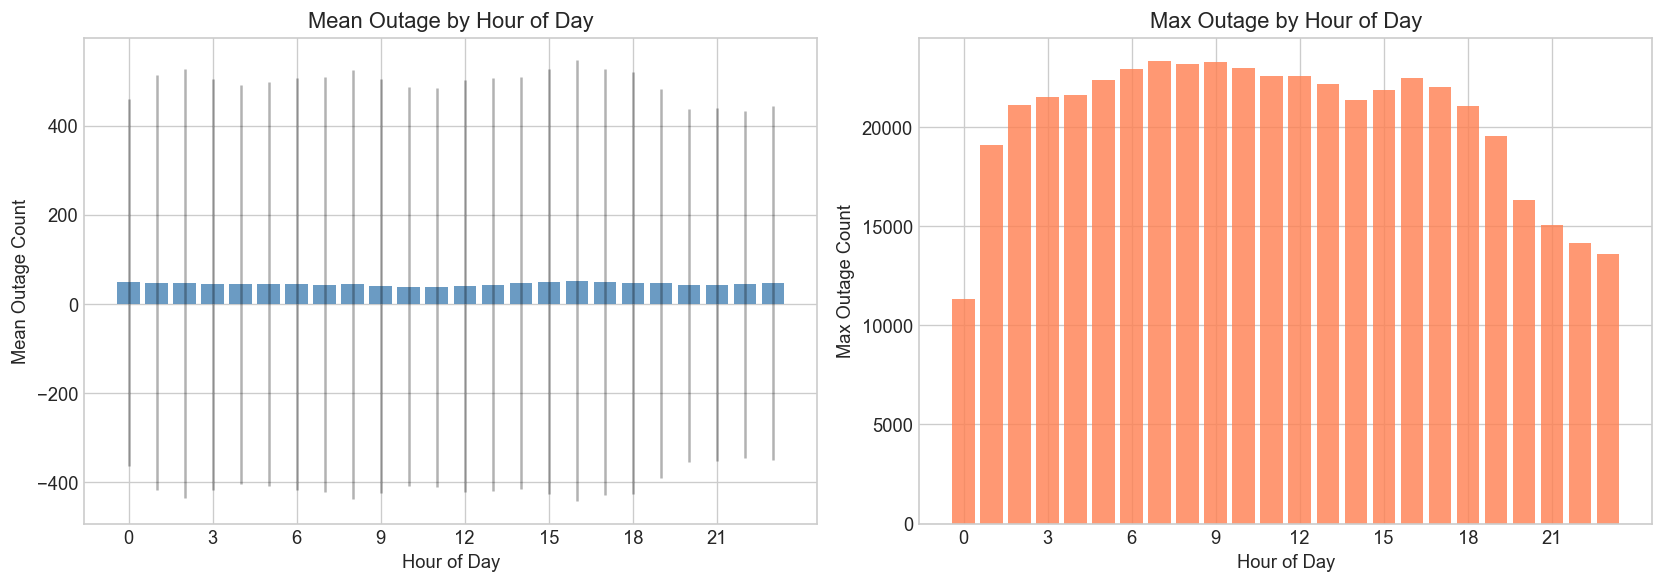


Peak hour:  16:00 (mean 52.8)
Low hour:   11:00 (mean 37.6)
Peak/Low ratio: 1.40x


In [28]:
# 3.2 Hour-of-day analysis — Is there a diurnal cycle?
hours = timestamps.hour

hourly_mean = np.zeros(24)
hourly_std = np.zeros(24)
hourly_max = np.zeros(24)

for h in range(24):
    mask = hours == h
    vals = out[mask].flatten()
    hourly_mean[h] = np.nanmean(vals)
    hourly_std[h] = np.nanstd(vals)
    hourly_max[h] = np.nanmax(vals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean outage by hour
axes[0].bar(range(24), hourly_mean, color='steelblue', alpha=0.8)
axes[0].errorbar(range(24), hourly_mean, yerr=hourly_std, fmt='none', color='black', alpha=0.3)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean Outage Count')
axes[0].set_title('Mean Outage by Hour of Day')
axes[0].set_xticks(range(0, 24, 3))

# Max outage by hour
axes[1].bar(range(24), hourly_max, color='coral', alpha=0.8)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Max Outage Count')
axes[1].set_title('Max Outage by Hour of Day')
axes[1].set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

peak_hour = np.argmax(hourly_mean)
low_hour = np.argmin(hourly_mean)
print(f'\nPeak hour:  {peak_hour}:00 (mean {hourly_mean[peak_hour]:.1f})')
print(f'Low hour:   {low_hour}:00 (mean {hourly_mean[low_hour]:.1f})')
print(f'Peak/Low ratio: {hourly_mean[peak_hour]/hourly_mean[low_hour]:.2f}x')

If a clear diurnal pattern exists, adding hour_of_day as a feature will help.

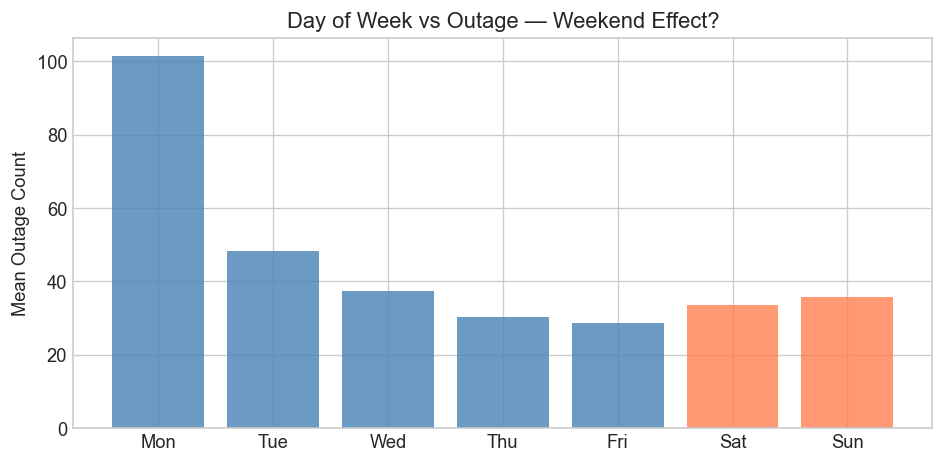

Weekday mean: 49.21
Weekend mean: 34.74
Difference:   29.4%


In [ ]:
# 3.3 Day-of-week pattern
dow = timestamps.dayofweek  # 0=Monday
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

dow_mean = [np.nanmean(out[dow == d]) for d in range(7)]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue']*5 + ['coral']*2  # weekday vs weekend
ax.bar(dow_names, dow_mean, color=colors, alpha=0.8)
ax.set_ylabel('Mean Outage Count')
ax.set_title('Day of Week vs Outage — Weekend Effect?')
plt.tight_layout()
plt.show()

weekday_mean = np.mean(dow_mean[:5])
weekend_mean = np.mean(dow_mean[5:])
print(f'Weekday mean: {weekday_mean:.2f}')
print(f'Weekend mean: {weekend_mean:.2f}')
print(f'Difference:   {abs(weekday_mean-weekend_mean)/weekday_mean*100:.1f}%')

## 4. Spatial Patterns

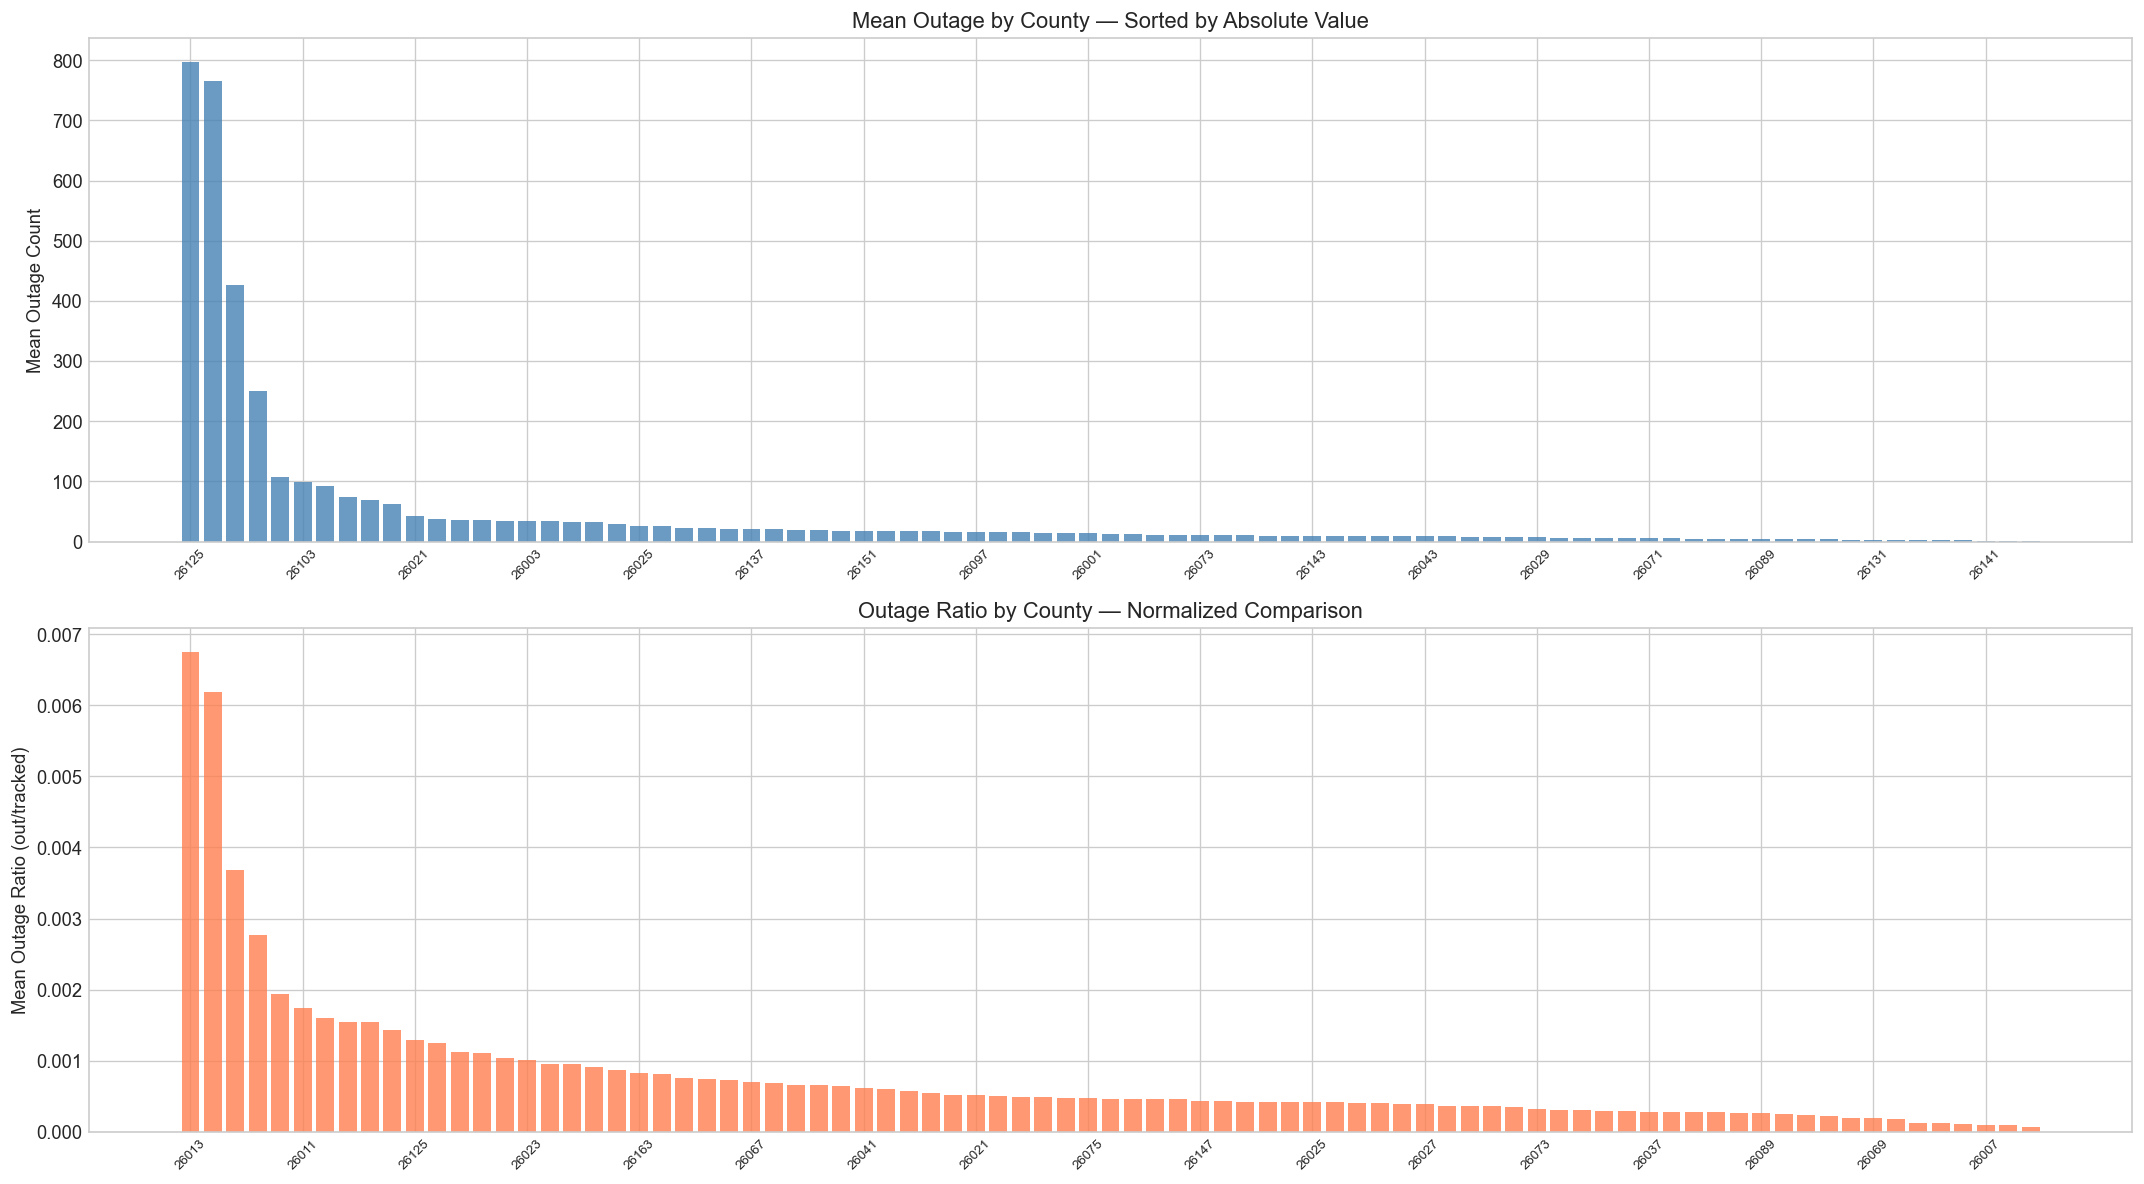

Top 10 counties by absolute outage count:
  26125: mean=797.7, max=23346, tracked=618067
  26163: mean=764.8, max=15143, tracked=922425
  26099: mean=426.0, max=17047, tracked=413676
  26161: mean=249.9, max=11889, tracked=174443
  26081: mean=108.1, max=6841, tracked=297421
  26103: mean=98.9, max=7078, tracked=15973
  26145: mean=92.6, max=8704, tracked=97158
  26093: mean=73.8, max=2800, tracked=90497
  26115: mean=69.4, max=2817, tracked=75792
  26049: mean=61.8, max=5878, tracked=206652

Top 10 counties by outage ratio (normalized):
  26013: ratio=0.0068, mean_out=15.4, tracked=2278
  26103: ratio=0.0062, mean_out=98.9, tracked=15973
  26003: ratio=0.0037, mean_out=34.0, tracked=9217
  26039: ratio=0.0028, mean_out=33.0, tracked=11887
  26053: ratio=0.0019, mean_out=20.1, tracked=10349
  26011: ratio=0.0017, mean_out=19.8, tracked=11370
  26097: ratio=0.0016, mean_out=15.7, tracked=9849
  26059: ratio=0.0015, mean_out=32.6, tracked=20706
  26095: ratio=0.0015, mean_out=3.3, tracke

In [31]:
# 4.1 County-level outage statistics
county_mean = np.nanmean(out, axis=0)          # (L,)
county_std = np.nanstd(out, axis=0)
county_max = np.nanmax(out, axis=0)
county_tracked = np.nanmean(tracked, axis=0)    # mean tracked customers
county_ratio = np.nanmean(out / tracked, axis=0) # mean outage ratio

# Sort by mean outage
sort_idx = np.argsort(county_mean)[::-1]

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# (a) Mean outage by county (absolute)
x_labels = [locations[i] for i in sort_idx]
axes[0].bar(range(L), county_mean[sort_idx], color='steelblue', alpha=0.8)
axes[0].set_ylabel('Mean Outage Count')
axes[0].set_title('Mean Outage by County — Sorted by Absolute Value')
axes[0].set_xticks(range(0, L, 5))
axes[0].set_xticklabels([x_labels[i] for i in range(0, L, 5)], rotation=45, fontsize=8)

# (b) Outage ratio by county (normalized)
sort_idx_ratio = np.argsort(county_ratio)[::-1]
x_labels_ratio = [locations[i] for i in sort_idx_ratio]
axes[1].bar(range(L), county_ratio[sort_idx_ratio], color='coral', alpha=0.8)
axes[1].set_ylabel('Mean Outage Ratio (out/tracked)')
axes[1].set_title('Outage Ratio by County — Normalized Comparison')
axes[1].set_xticks(range(0, L, 5))
axes[1].set_xticklabels([x_labels_ratio[i] for i in range(0, L, 5)], rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

print('Top 10 counties by absolute outage count:')
for i in range(10):
    idx = sort_idx[i]
    print(f'  {locations[idx]}: mean={county_mean[idx]:.1f}, max={county_max[idx]:.0f}, tracked={county_tracked[idx]:.0f}')

print('\nTop 10 counties by outage ratio (normalized):')
for i in range(10):
    idx = sort_idx_ratio[i]
    print(f'  {locations[idx]}: ratio={county_ratio[idx]:.4f}, mean_out={county_mean[idx]:.1f}, tracked={county_tracked[idx]:.0f}')

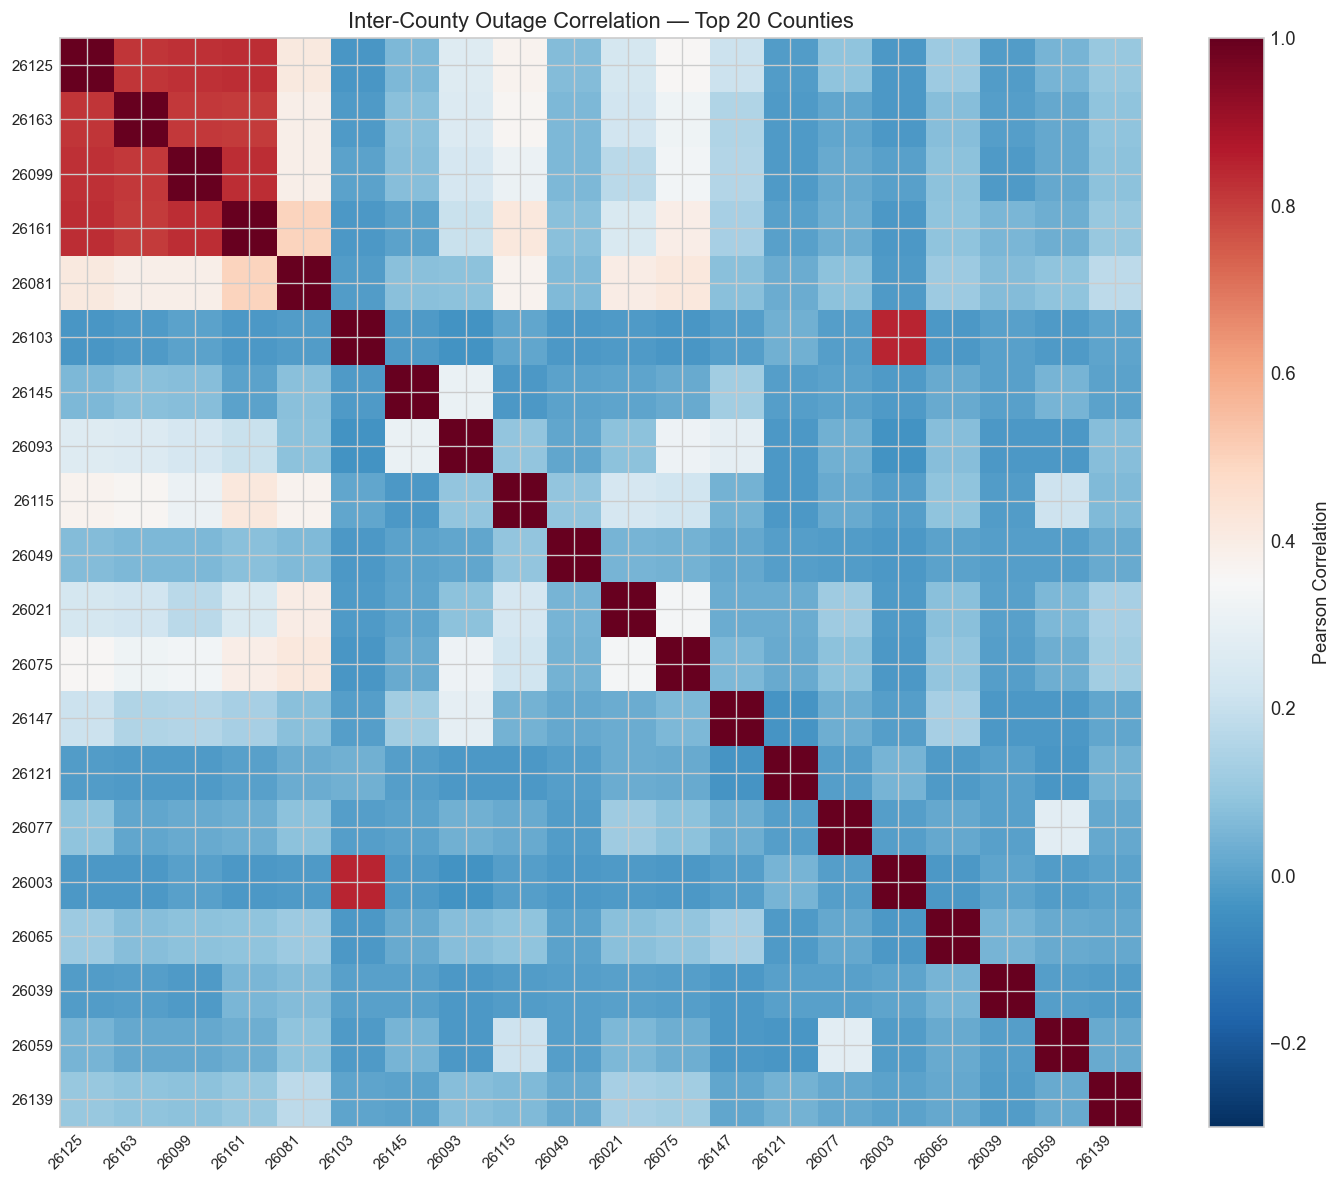


Inter-county correlation statistics:
  Mean:           0.106
  Pairs > 0.5:    7
  Pairs > 0.3:    25

=> Weak inter-county correlation. Counties can be modeled independently.


In [11]:
# 4.2 Inter-county outage correlation matrix — detecting spatial propagation
# Use top 20 counties by outage count for visualization
top20_idx = sort_idx[:20]
top20_labels = [locations[i] for i in top20_idx]
top20_out = out[:, top20_idx]  # (T, 20)

corr_matrix = np.corrcoef(top20_out.T)  # (20, 20)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-0.3, vmax=1.0, aspect='auto')
ax.set_xticks(range(len(top20_labels)))
ax.set_yticks(range(len(top20_labels)))
ax.set_xticklabels(top20_labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(top20_labels, fontsize=9)
ax.set_title('Inter-County Outage Correlation — Top 20 Counties')
plt.colorbar(im, label='Pearson Correlation')
plt.tight_layout()
plt.show()

# Statistics on high-correlation pairs
upper_tri = corr_matrix[np.triu_indices(len(top20_labels), k=1)]
print(f'\nInter-county correlation statistics:')
print(f'  Mean:           {upper_tri.mean():.3f}')
print(f'  Pairs > 0.5:    {(upper_tri > 0.5).sum()}')
print(f'  Pairs > 0.3:    {(upper_tri > 0.3).sum()}')
if upper_tri.mean() > 0.2:
    print('\n=> Significant spatial correlation detected! GNN or neighbor features may be effective.')
else:
    print('\n=> Weak inter-county correlation. Counties can be modeled independently.')

## 5. Weather Feature Selection

Identifying which weather variables matter most for outage prediction.

In [12]:
# 5.1 Pearson correlation of each weather feature with outage (all counties pooled)
out_flat_all = out.flatten()  # (T*L,)

corr_with_outage = []
for f_idx, f_name in enumerate(features):
    weather_flat = weather[:, :, f_idx].flatten()  # (T*L,)
    
    # Drop NaN
    valid = ~(np.isnan(weather_flat) | np.isnan(out_flat_all))
    if valid.sum() > 100:
        r = np.corrcoef(weather_flat[valid], out_flat_all[valid])[0, 1]
    else:
        r = 0.0
    corr_with_outage.append((f_name, r, abs(r)))

# Sort by absolute correlation
corr_with_outage.sort(key=lambda x: -x[2])

print('=== Weather Feature Correlation Ranking (|Pearson r|) ===')
print(f'{"Rank":>4} {"Feature":<12} {"Correlation":>12} {"Abs":>8}')
print('-' * 40)
for i, (name, r, abs_r) in enumerate(corr_with_outage[:30]):
    print(f'{i+1:>4} {name:<12} {r:>+12.4f} {abs_r:>8.4f}')

=== Weather Feature Correlation Ranking (|Pearson r|) ===
Rank Feature       Correlation      Abs
----------------------------------------
   1 cape              +0.1192   0.1192
   2 gh_4              +0.0815   0.0815
   3 cape_1            +0.0733   0.0733
   4 lcc               +0.0554   0.0554
   5 hail              +0.0546   0.0546
   6 cnwat             +0.0544   0.0544
   7 pcdb              +0.0538   0.0538
   8 gh                -0.0528   0.0528
   9 lftx              -0.0526   0.0526
  10 lftx4             -0.0510   0.0510
  11 gh_3              +0.0504   0.0504
  12 mcc               +0.0490   0.0490
  13 gust              +0.0464   0.0464
  14 gh_5              -0.0429   0.0429
  15 lai               -0.0415   0.0415
  16 pres              +0.0396   0.0396
  17 hcc               +0.0378   0.0378
  18 fricv             +0.0377   0.0377
  19 SBT114            -0.0372   0.0372
  20 mstav             +0.0371   0.0371
  21 d2m               +0.0356   0.0356
  22 SBT124          

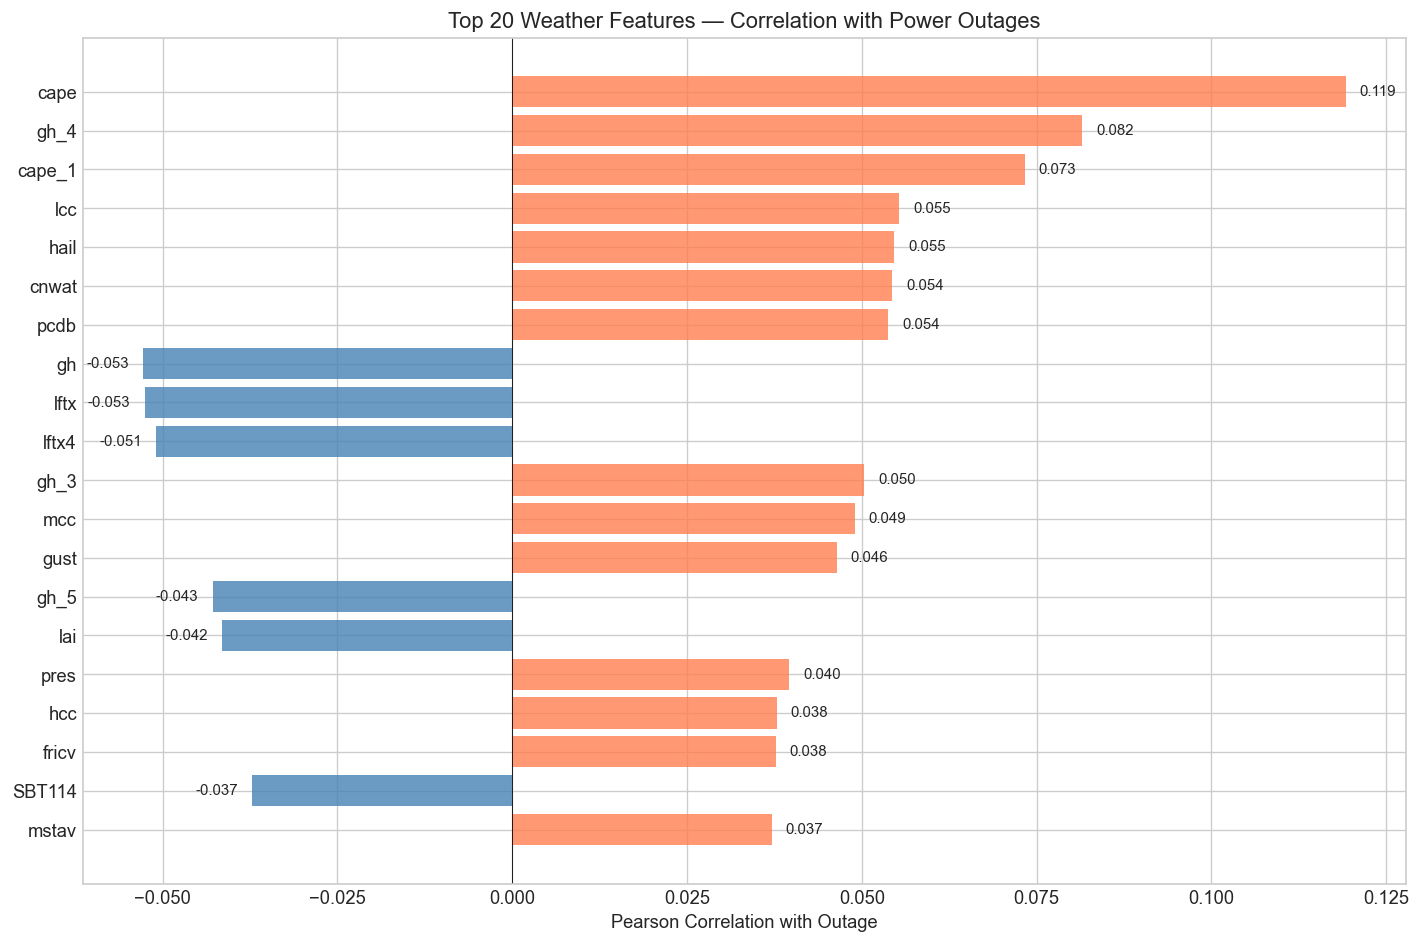

In [32]:
# 5.2 Visualization — Top 20 correlated features
top_n = 20
top_features = corr_with_outage[:top_n]

fig, ax = plt.subplots(figsize=(12, 8))
names = [x[0] for x in top_features][::-1]
values = [x[1] for x in top_features][::-1]
colors = ['coral' if v > 0 else 'steelblue' for v in values]

ax.barh(range(top_n), values, color=colors, alpha=0.8, edgecolor='none')
ax.set_yticks(range(top_n))
ax.set_yticklabels(names)
ax.set_xlabel('Pearson Correlation with Outage')
ax.set_title(f'Top {top_n} Weather Features — Correlation with Power Outages')
ax.axvline(0, color='black', linewidth=0.5)

for i, v in enumerate(values):
    ax.text(v + 0.002 if v > 0 else v - 0.002, i, f'{v:.3f}',
            va='center', ha='left' if v > 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()


Positively correlated features may directly drive outages.\
Negatively correlated features may indicate conditions that reduce outages.\
Note: Linear correlation misses non-linear relationships 

In [14]:
# 5.3 Non-linear analysis: comparing weather during extreme vs. normal outages
# Split all samples into "normal" and "extreme" groups
threshold_extreme = np.nanpercentile(out_flat_all, 95)
extreme_mask = out.flatten() > threshold_extreme
normal_mask = out.flatten() <= threshold_extreme

print(f'Extreme outage threshold (95th percentile): {threshold_extreme:.0f}')
print(f'Extreme samples: {extreme_mask.sum()} ({extreme_mask.mean()*100:.1f}%)')
print(f'Normal samples:  {normal_mask.sum()} ({normal_mask.mean()*100:.1f}%)')

# Compute standardized mean difference (Cohen's d) for each feature
diff_list = []
for f_idx, f_name in enumerate(features):
    w_flat = weather[:, :, f_idx].flatten()
    
    extreme_vals = w_flat[extreme_mask & ~np.isnan(w_flat)]
    normal_vals = w_flat[normal_mask & ~np.isnan(w_flat)]
    
    if len(extreme_vals) > 10 and len(normal_vals) > 10 and np.std(normal_vals) > 0:
        pooled_std = np.sqrt((np.var(normal_vals) + np.var(extreme_vals)) / 2)
        if pooled_std > 0:
            cohens_d = (np.mean(extreme_vals) - np.mean(normal_vals)) / pooled_std
        else:
            cohens_d = 0.0
        diff_list.append((f_name, cohens_d, abs(cohens_d),
                          np.mean(normal_vals), np.mean(extreme_vals)))

diff_list.sort(key=lambda x: -x[2])

print(f'\n=== Extreme vs Normal Outage — Weather Feature Differences (Cohen\'s d) ===')
print(f'{"Rank":>4} {"Feature":<12} {"Cohen d":>10} {"Normal Mean":>14} {"Extreme Mean":>14}')
print('-' * 60)
for i, (name, d, abs_d, nm, em) in enumerate(diff_list[:20]):
    print(f'{i+1:>4} {name:<12} {d:>+10.3f} {nm:>14.2f} {em:>14.2f}')

Extreme outage threshold (95th percentile): 100
Extreme samples: 8934 (5.0%)
Normal samples:  170429 (95.0%)

=== Extreme vs Normal Outage — Weather Feature Differences (Cohen's d) ===
Rank Feature         Cohen d    Normal Mean   Extreme Mean
------------------------------------------------------------
   1 lai              -0.476           1.60           1.01
   2 gh_4             +0.371        1441.92        2577.64
   3 pwat             +0.366          14.86          18.10
   4 sdlwrf           +0.362         305.72         322.48
   5 fricv            +0.348           0.23           0.29
   6 cape             +0.337           4.03          10.92
   7 gust             +0.328           5.92           7.23
   8 cnwat            +0.325           0.02           0.06
   9 sh2              +0.322           0.01           0.01
  10 tcc              +0.297          39.65          52.97
  11 orog             -0.295         266.02         244.88
  12 gh_3             +0.289         992.60   

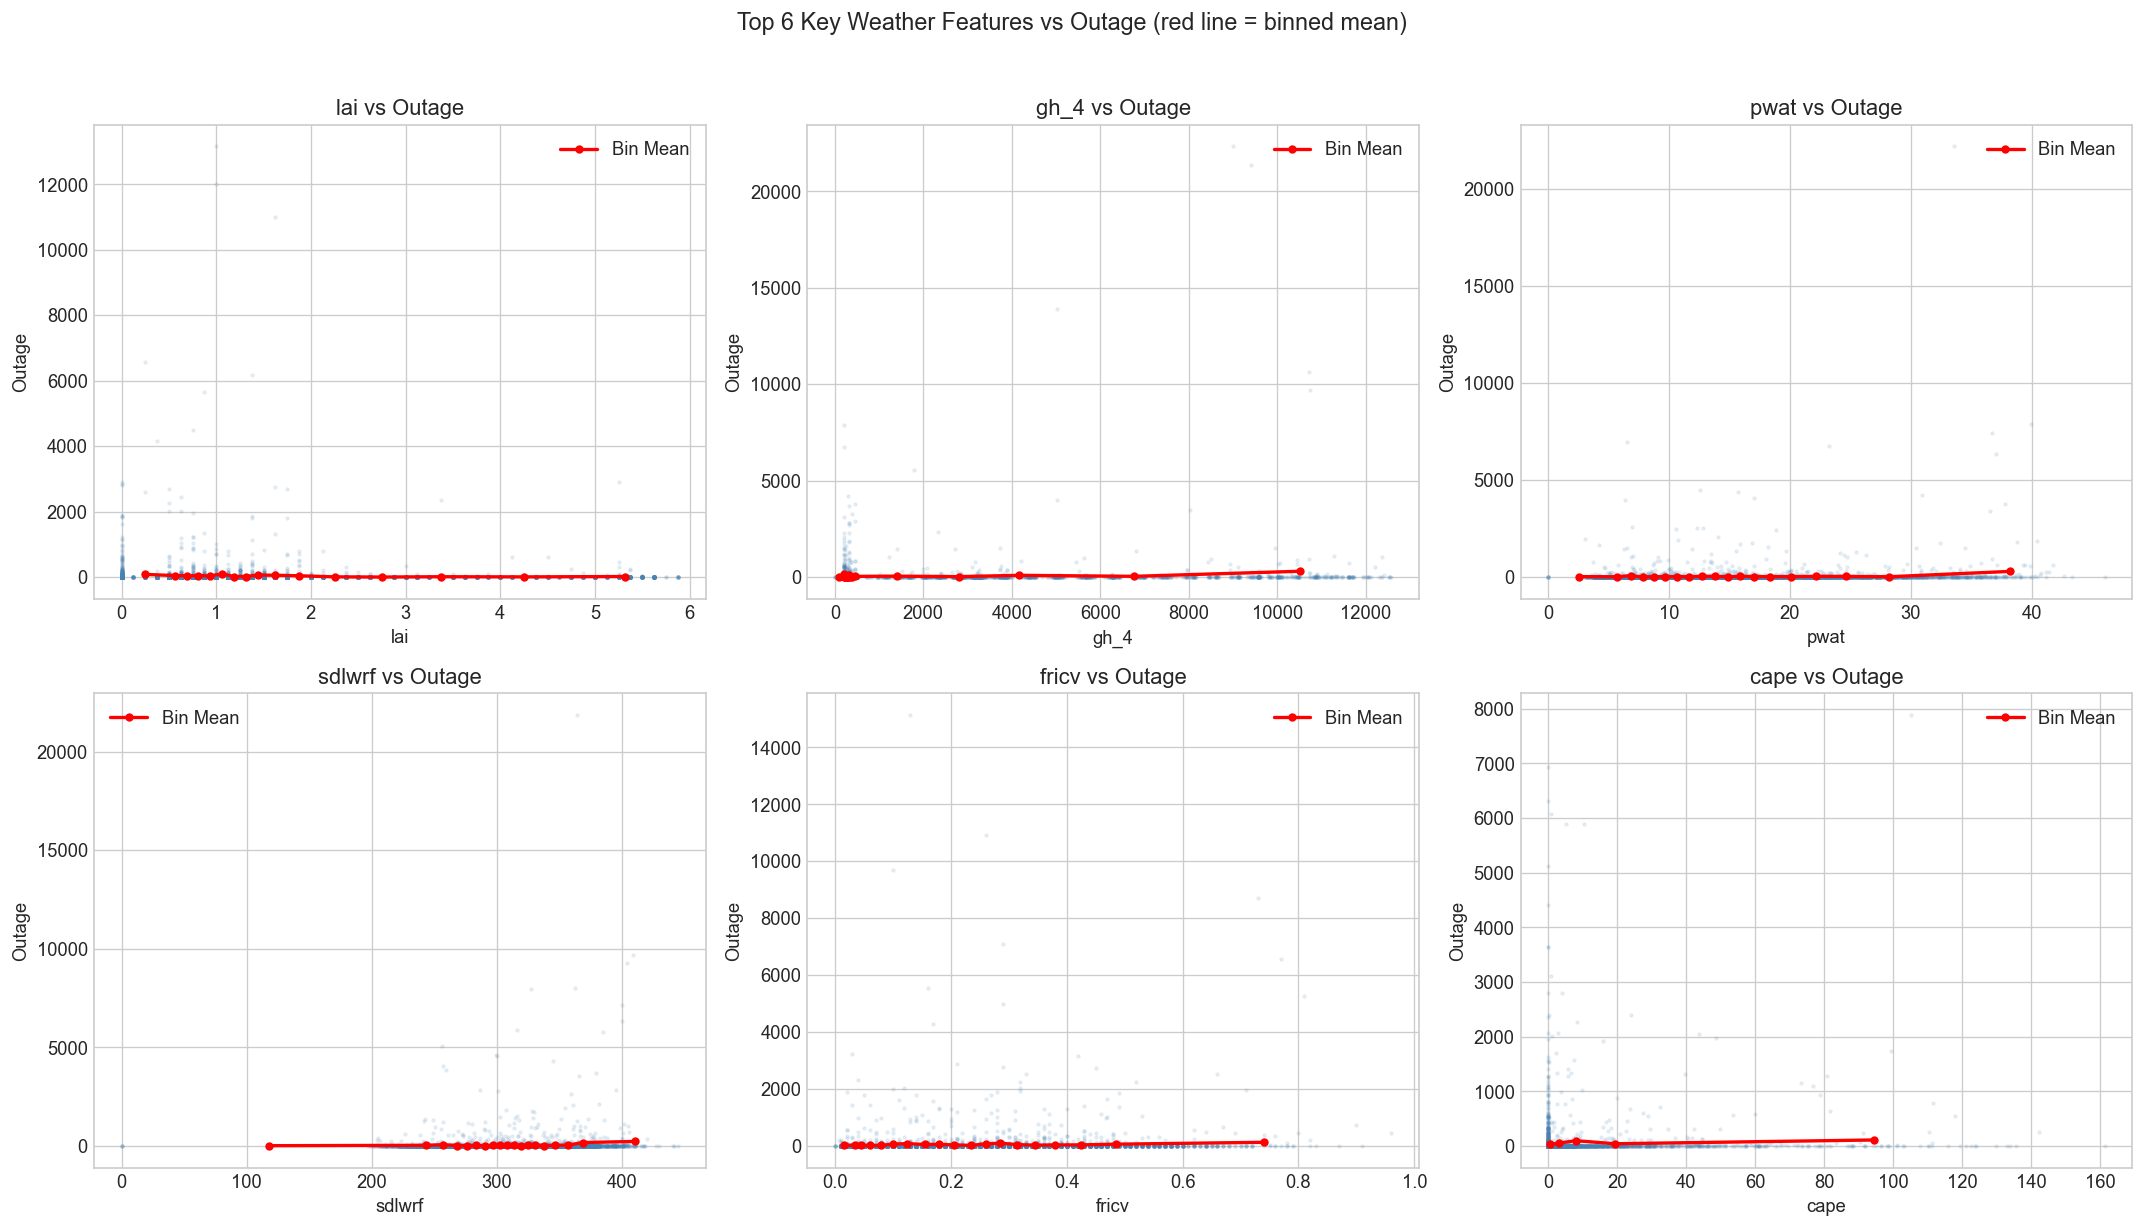

In [33]:
# 5.4 Scatter plots for top 6 key features with binned mean overlay
top6 = [x[0] for x in diff_list[:6]]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, f_name in enumerate(top6):
    f_idx = features.index(f_name)
    w_flat = weather[:, :, f_idx].flatten()
    o_flat = out.flatten()
    
    # Subsample to avoid overplotting
    valid = ~(np.isnan(w_flat) | np.isnan(o_flat))
    idx_valid = np.where(valid)[0]
    if len(idx_valid) > 5000:
        sample_idx = np.random.choice(idx_valid, 5000, replace=False)
    else:
        sample_idx = idx_valid
    
    axes[i].scatter(w_flat[sample_idx], o_flat[sample_idx],
                    alpha=0.1, s=3, color='steelblue')
    axes[i].set_xlabel(f_name)
    axes[i].set_ylabel('Outage')
    axes[i].set_title(f'{f_name} vs Outage')
    
    # Binned mean line
    w_sample = w_flat[sample_idx]
    o_sample = o_flat[sample_idx]
    bins = np.percentile(w_sample[~np.isnan(w_sample)], np.linspace(0, 100, 20))
    bins = np.unique(bins)
    if len(bins) > 2:
        bin_centers = []
        bin_means = []
        for b in range(len(bins)-1):
            mask = (w_sample >= bins[b]) & (w_sample < bins[b+1])
            if mask.sum() > 5:
                bin_centers.append((bins[b] + bins[b+1]) / 2)
                bin_means.append(np.mean(o_sample[mask]))
        axes[i].plot(bin_centers, bin_means, color='red', linewidth=2,
                     marker='o', markersize=4, label='Bin Mean')
        axes[i].legend()

plt.suptitle('Top 6 Key Weather Features vs Outage (red line = binned mean)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

(Red lines reveal non-linear relationships: outages spike after certain thresholds.)

## 6. Feature Redundancy Analysis

Valid features: 87 / 109


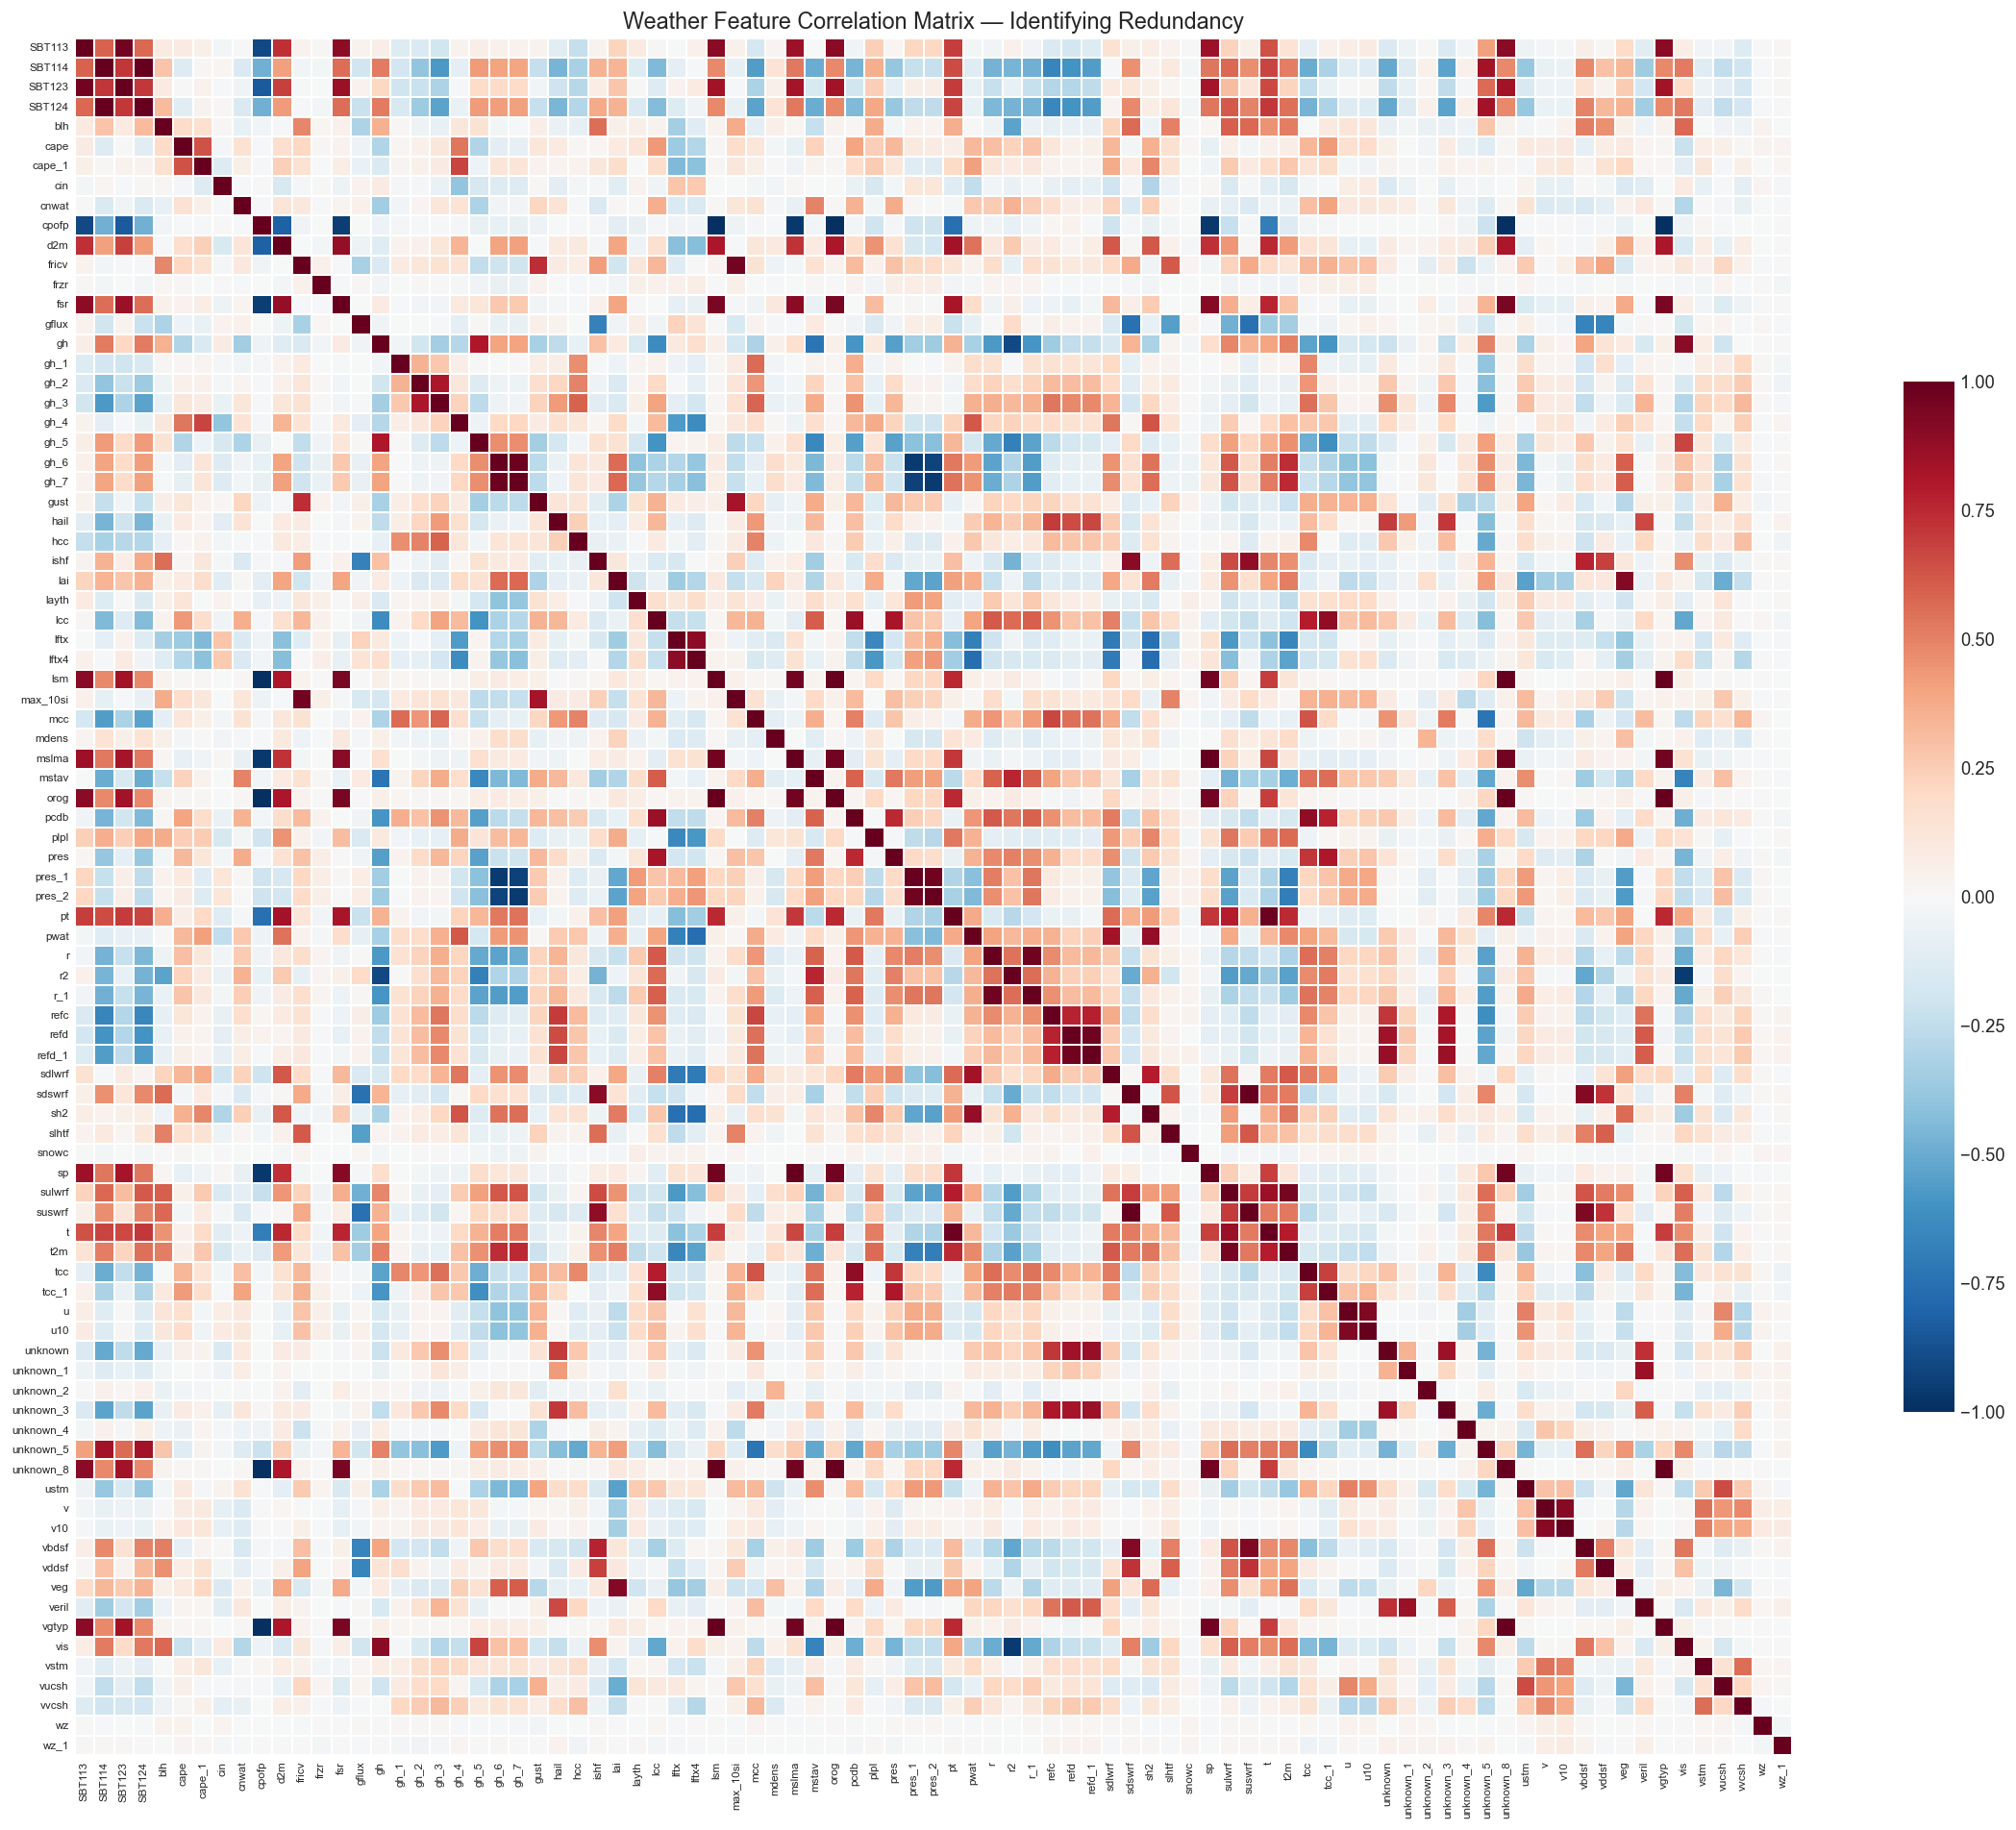

In [16]:
# 6.1 Inter-feature correlation matrix
# Use one representative county (the one with most outages)
mid_county_idx = sort_idx[0]
weather_one_county = weather[:, mid_county_idx, :]  # (T, F)

# Drop columns that are all NaN or constant
valid_features = []
valid_indices = []
for f_idx in range(F):
    col = weather_one_county[:, f_idx]
    if np.sum(~np.isnan(col)) > T * 0.5 and np.nanstd(col) > 0:
        valid_features.append(features[f_idx])
        valid_indices.append(f_idx)

weather_valid = weather_one_county[:, valid_indices]  # (T, F_valid)
print(f'Valid features: {len(valid_features)} / {F}')

# Compute correlation matrix via pandas (handles NaN)
df_weather = pd.DataFrame(weather_valid, columns=valid_features)
corr_features = df_weather.corr()

# Heatmap
fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(corr_features, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=True, yticklabels=True, ax=ax,
            square=True, linewidths=0.1, cbar_kws={'shrink': 0.6})
ax.set_title('Weather Feature Correlation Matrix — Identifying Redundancy', fontsize=14)
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.show()

In [17]:
# 6.2 List highly redundant feature pairs
high_corr_pairs = []
corr_matrix_np = corr_features.values
feature_names_valid = corr_features.columns.tolist()

for i in range(len(feature_names_valid)):
    for j in range(i+1, len(feature_names_valid)):
        r = corr_matrix_np[i, j]
        if abs(r) > 0.9 and not np.isnan(r):
            high_corr_pairs.append((feature_names_valid[i], feature_names_valid[j], r))

high_corr_pairs.sort(key=lambda x: -abs(x[2]))

print(f'Highly correlated pairs (|r| > 0.9): {len(high_corr_pairs)} pairs')
print(f'\n{"Feature A":<12} {"Feature B":<12} {"Correlation":>12}')
print('-' * 38)
for a, b, r in high_corr_pairs[:20]:
    print(f'{a:<12} {b:<12} {r:>+12.4f}')

print(f'\n=> These pairs are highly redundant — keep only one from each pair.')
print(f'   Consider PCA or correlation-based feature selection for dimensionality reduction.')

Highly correlated pairs (|r| > 0.9): 49 pairs

Feature A    Feature B     Correlation
--------------------------------------
orog         vgtyp             +1.0000
lsm          vgtyp             +1.0000
lsm          unknown_8         +1.0000
cpofp        orog              -1.0000
orog         unknown_8         +1.0000
cpofp        lsm               -1.0000
unknown_8    vgtyp             +1.0000
cpofp        unknown_8         -1.0000
cpofp        vgtyp             -1.0000
lsm          orog              +1.0000
mslma        sp                +0.9997
sdswrf       suswrf            +0.9972
SBT114       SBT124            +0.9958
gh_6         gh_7              +0.9778
pt           t                 +0.9773
pres_1       pres_2            +0.9733
r            r_1               +0.9713
refd         refd_1            +0.9706
fricv        max_10si          +0.9653
lsm          mslma             +0.9646

=> These pairs are highly redundant — keep only one from each pair.
   Consider PCA or correla

## 7. Extreme Event Analysis

=== Top 10 Worst Outage Hours ===
Rank Timestamp               Total Outages
--------------------------------------------
   1 2023-06-26 01:00:00             86313
   2 2023-06-26 02:00:00             82961
   3 2023-06-26 03:00:00             81105
   4 2023-06-26 04:00:00             75415
   5 2023-06-26 06:00:00             75250
   6 2023-06-26 05:00:00             74942
   7 2023-06-26 17:00:00             74501
   8 2023-06-26 07:00:00             74281
   9 2023-06-26 16:00:00             72898
  10 2023-06-26 15:00:00             72884


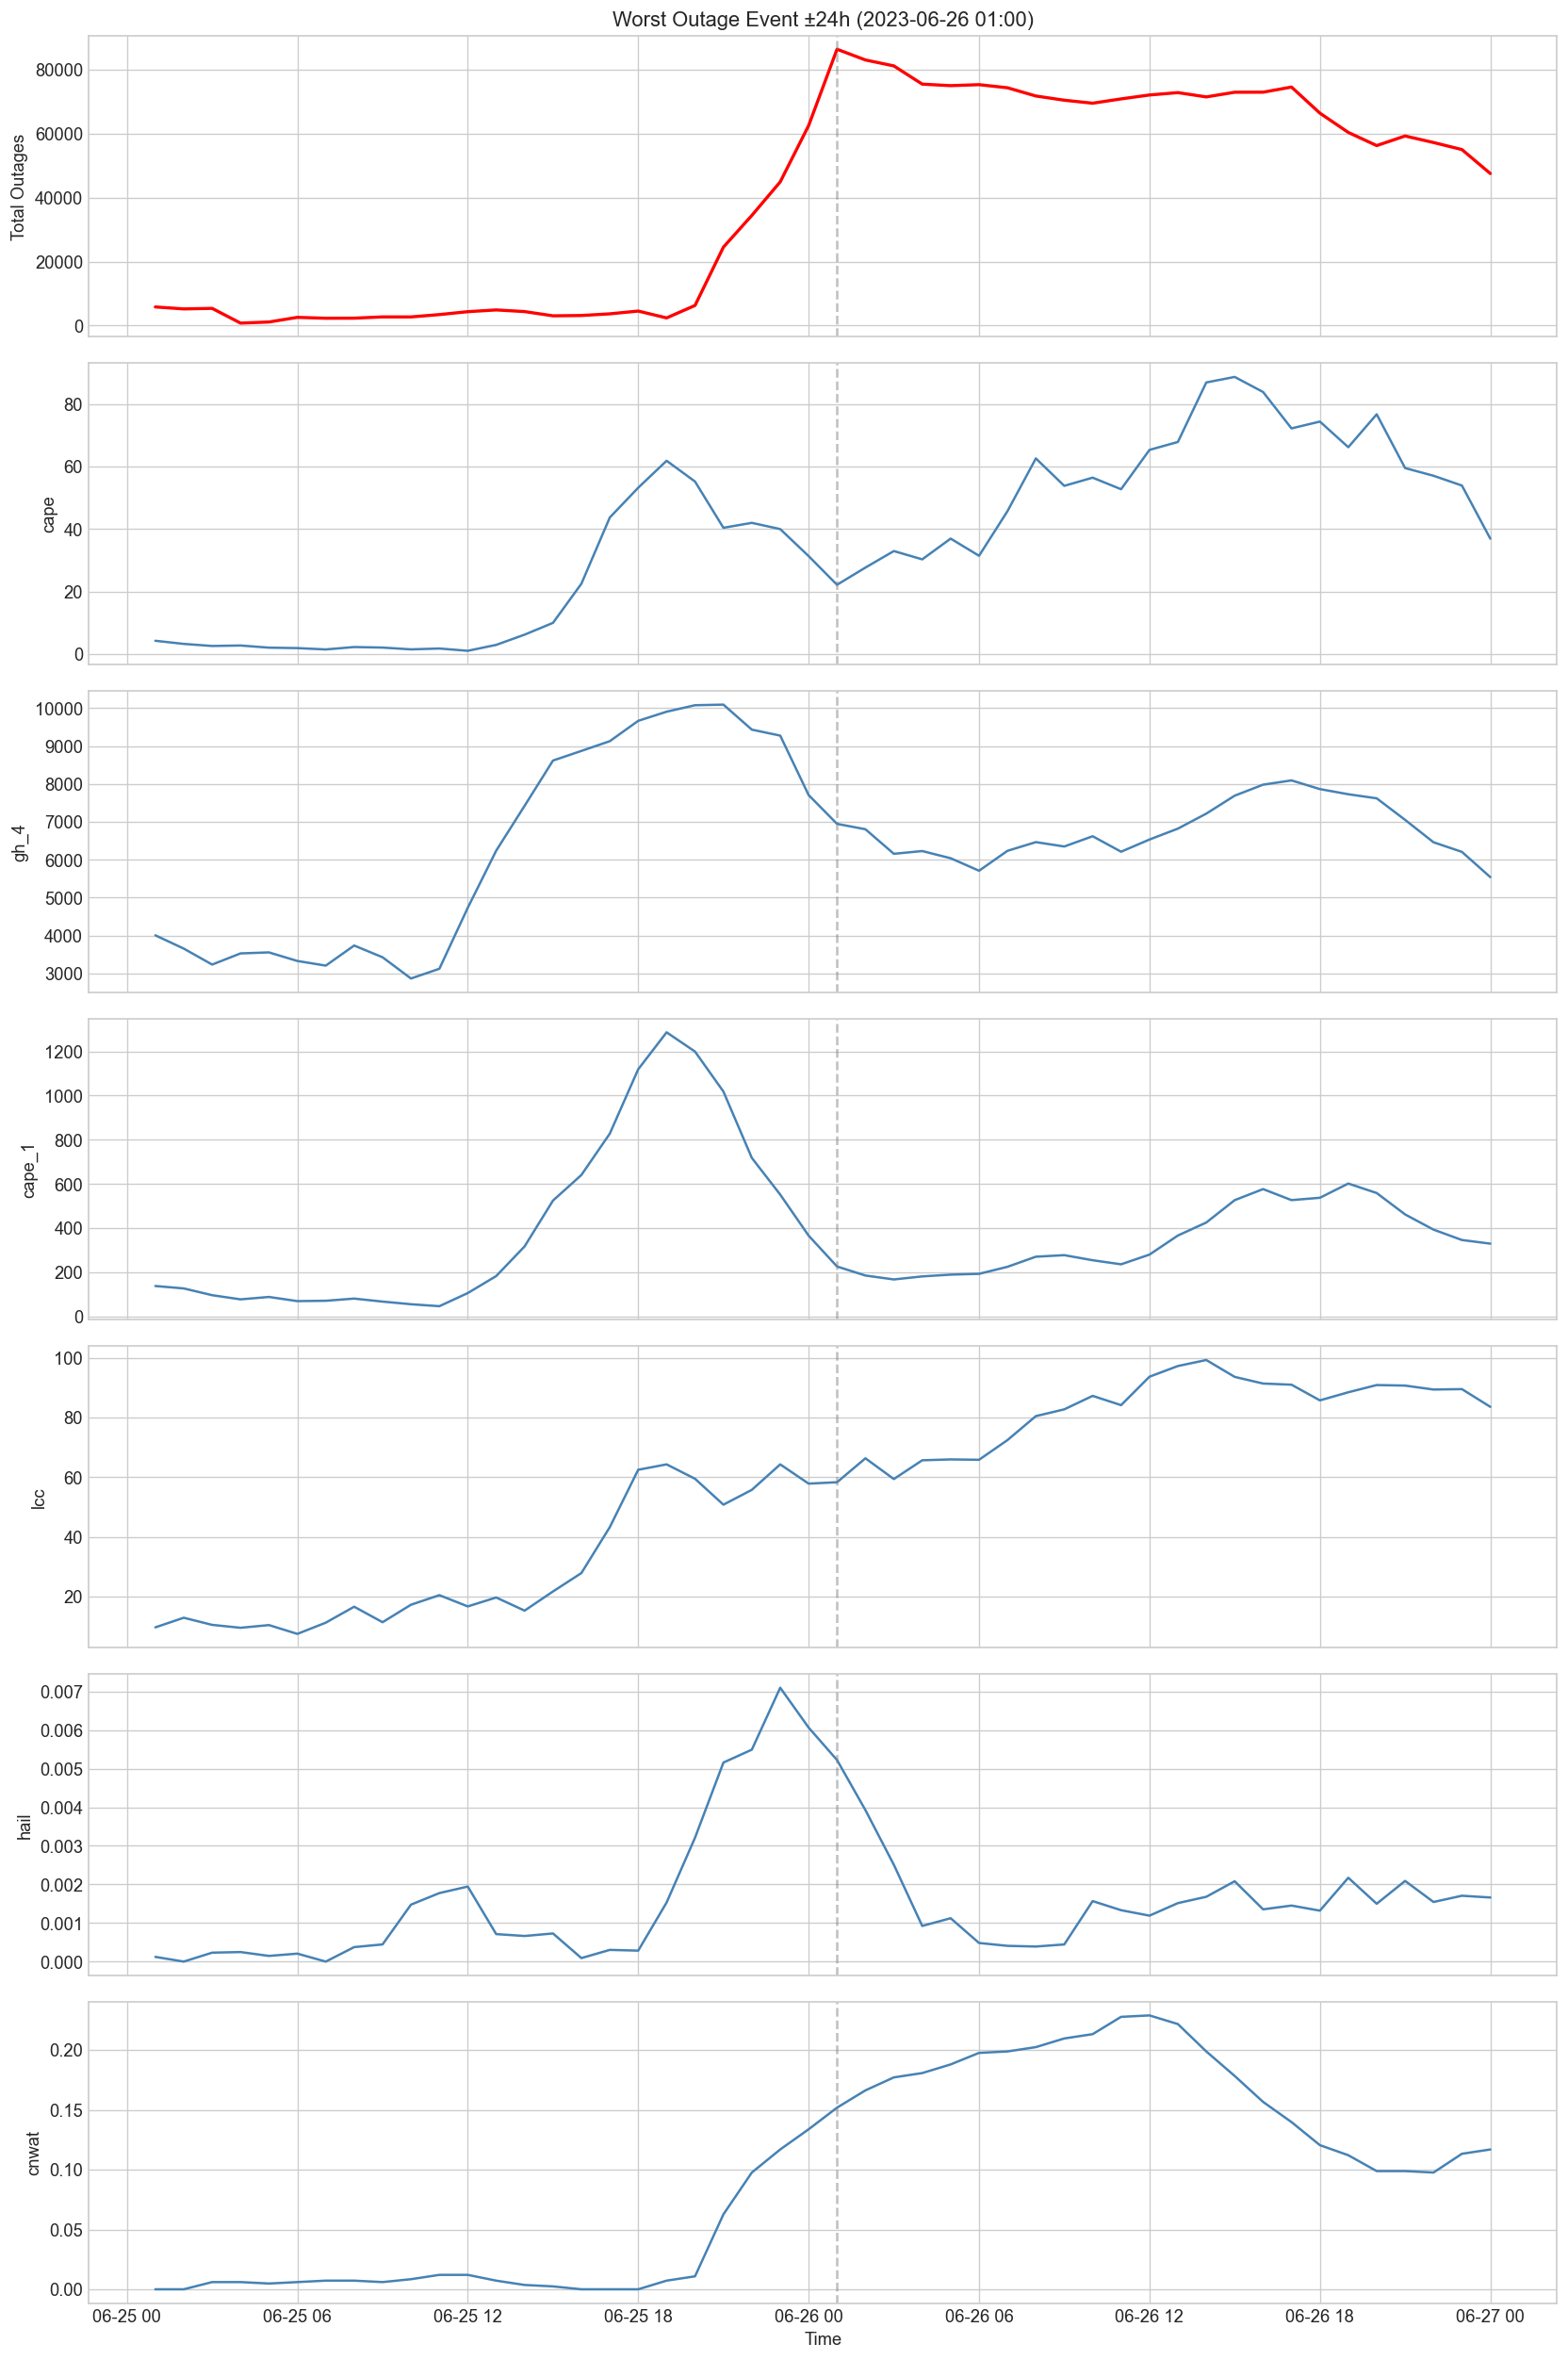

In [34]:
# 7.1 Analyze weather conditions around the worst outage events
total_per_hour = np.nansum(out, axis=1)  # (T,)
top_event_indices = np.argsort(total_per_hour)[::-1][:10]

print('=== Top 10 Worst Outage Hours ===')
print(f'{"Rank":>4} {"Timestamp":<22} {"Total Outages":>14}')
print('-' * 44)
for i, idx in enumerate(top_event_indices):
    print(f'{i+1:>4} {str(timestamps[idx])[:19]:<22} {total_per_hour[idx]:>14.0f}')

# Zoom into the worst event: weather changes ±24h around peak
peak_idx = top_event_indices[0]
window_start = max(0, peak_idx - 24)
window_end = min(T, peak_idx + 24)

# Use top 6 correlated weather features
top_weather_names = [x[0] for x in corr_with_outage[:6]]

fig, axes = plt.subplots(len(top_weather_names) + 1, 1,
                          figsize=(14, 3*(len(top_weather_names)+1)),
                          sharex=True)

time_window = timestamps[window_start:window_end]

# Total outages
axes[0].plot(time_window, total_per_hour[window_start:window_end],
             color='red', linewidth=2)
axes[0].axvline(timestamps[peak_idx], color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Total Outages')
axes[0].set_title(f'Worst Outage Event \u00b124h ({str(timestamps[peak_idx])[:16]})')

# Weather features
for i, f_name in enumerate(top_weather_names):
    f_idx = features.index(f_name)
    weather_mean = np.nanmean(weather[window_start:window_end, :, f_idx], axis=1)
    axes[i+1].plot(time_window, weather_mean, color='steelblue', linewidth=1.5)
    axes[i+1].axvline(timestamps[peak_idx], color='gray', linestyle='--', alpha=0.5)
    axes[i+1].set_ylabel(f_name)

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()


Observe whether weather indicators start changing BEFORE the outage peak.\
This determines the effective prediction lead time for the model.

**Extreme Event Analysis — (2023-06-26 storm event)**

The plot shows the worst outage event in the dataset (peaking at ~85,000 total outages on 2023-06-26 01:00) alongside 6 weather features over a ±24h window.

**1. Weather signals lead outages by ~4-12 hours.** Starting around 06-25 12:00 (roughly 12 hours before the outage peak), cape, cape_1, gh_4, lcc, and hail all begin rising sharply. This confirms that storm buildup is detectable well before outages spike, which is valuable since we can only use historical weather at test time.

**2. Hail shows the sharpest signal.** It spikes just a few hours before the peak and drops quickly afterward — characteristic of a severe convective storm. This kind of short, intense signal could be a strong predictor if captured within the lookback window.

**3. cape_1 peaks before outages peak.** cape_1 reaches ~1200 around 06-25 18:00-21:00, while outages peak at 06-26 01:00 — a lead time of about 4-7 hours. This aligns with the cross-correlation lag results.

**4. Outage recovery is slow and driven by repair, not weather.** After the peak, weather indicators (cape, lcc, cnwat) remain elevated or even rise further, yet outages gradually decline over 24+ hours. This means the decline reflects utility repair efforts rather than weather improvement, highlighting the importance of autoregressive features (i.e., recent outage history is a strong predictor of near-future outage levels).

**Modeling implications:** A lookback window of 24-48h should capture pre-storm weather signals. The slow recovery pattern means past outage values carry strong predictive power for the forecast horizon. Both historical weather context and autoregressive outage features should be core model inputs.

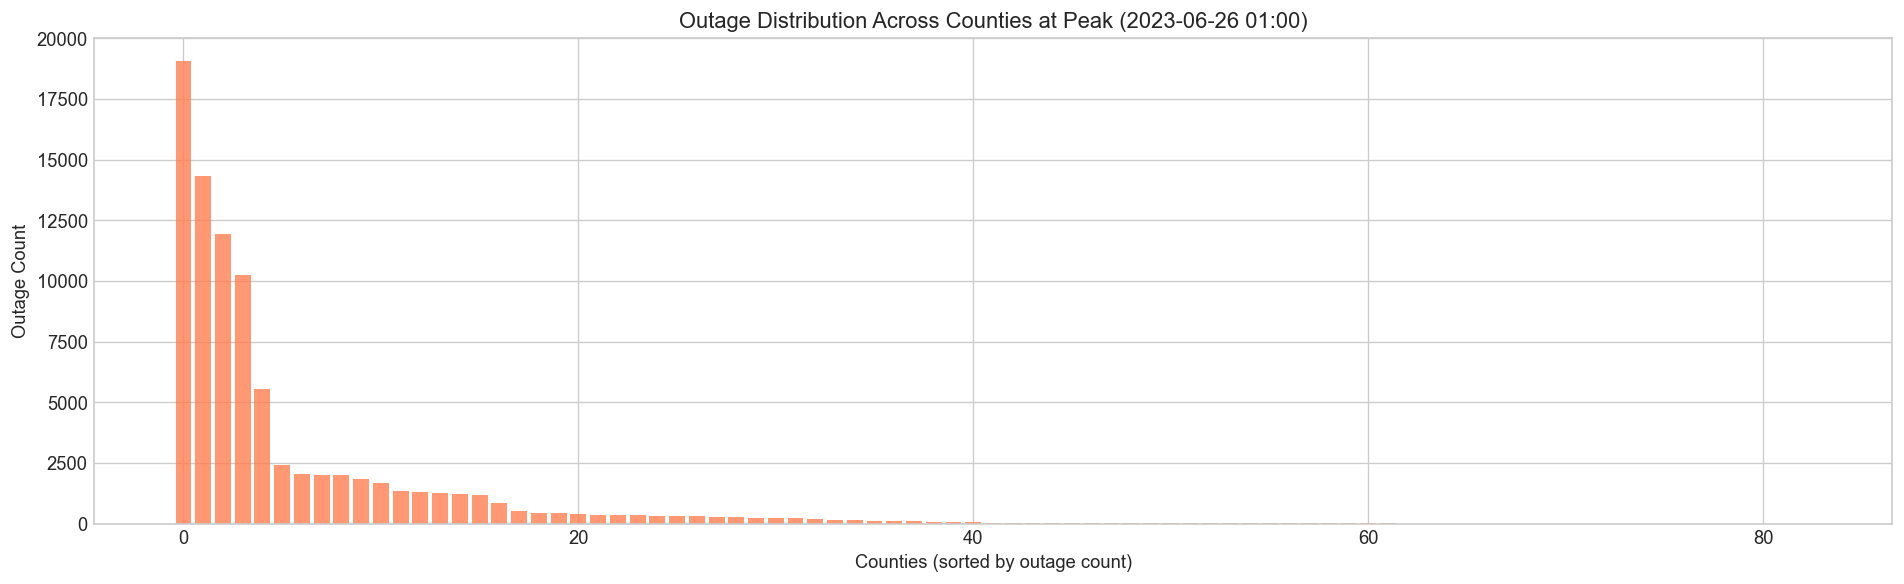


Counties above 75th percentile at peak: 21/83


In [35]:
# 7.2 Spatial distribution during peak event — are outages concentrated or widespread?
peak_idx = top_event_indices[0]
outage_at_peak = out[peak_idx, :]  # (L,)

sort_by_peak = np.argsort(outage_at_peak)[::-1]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(L), outage_at_peak[sort_by_peak], color='coral', alpha=0.8)
ax.set_ylabel('Outage Count')
ax.set_title(f'Outage Distribution Across Counties at Peak ({str(timestamps[peak_idx])[:16]})')
ax.set_xlabel('Counties (sorted by outage count)')
plt.tight_layout()
plt.show()

affected = (outage_at_peak > np.nanpercentile(outage_at_peak, 75)).sum()
print(f'\nCounties above 75th percentile at peak: {affected}/{L}')

Many counties are affected simultaneously, large-scale storms dominate — spatial modeling matters.

## 8. Time Lag Analysis

How many hours do key weather features lead outages? It determines the optimal lookback window.

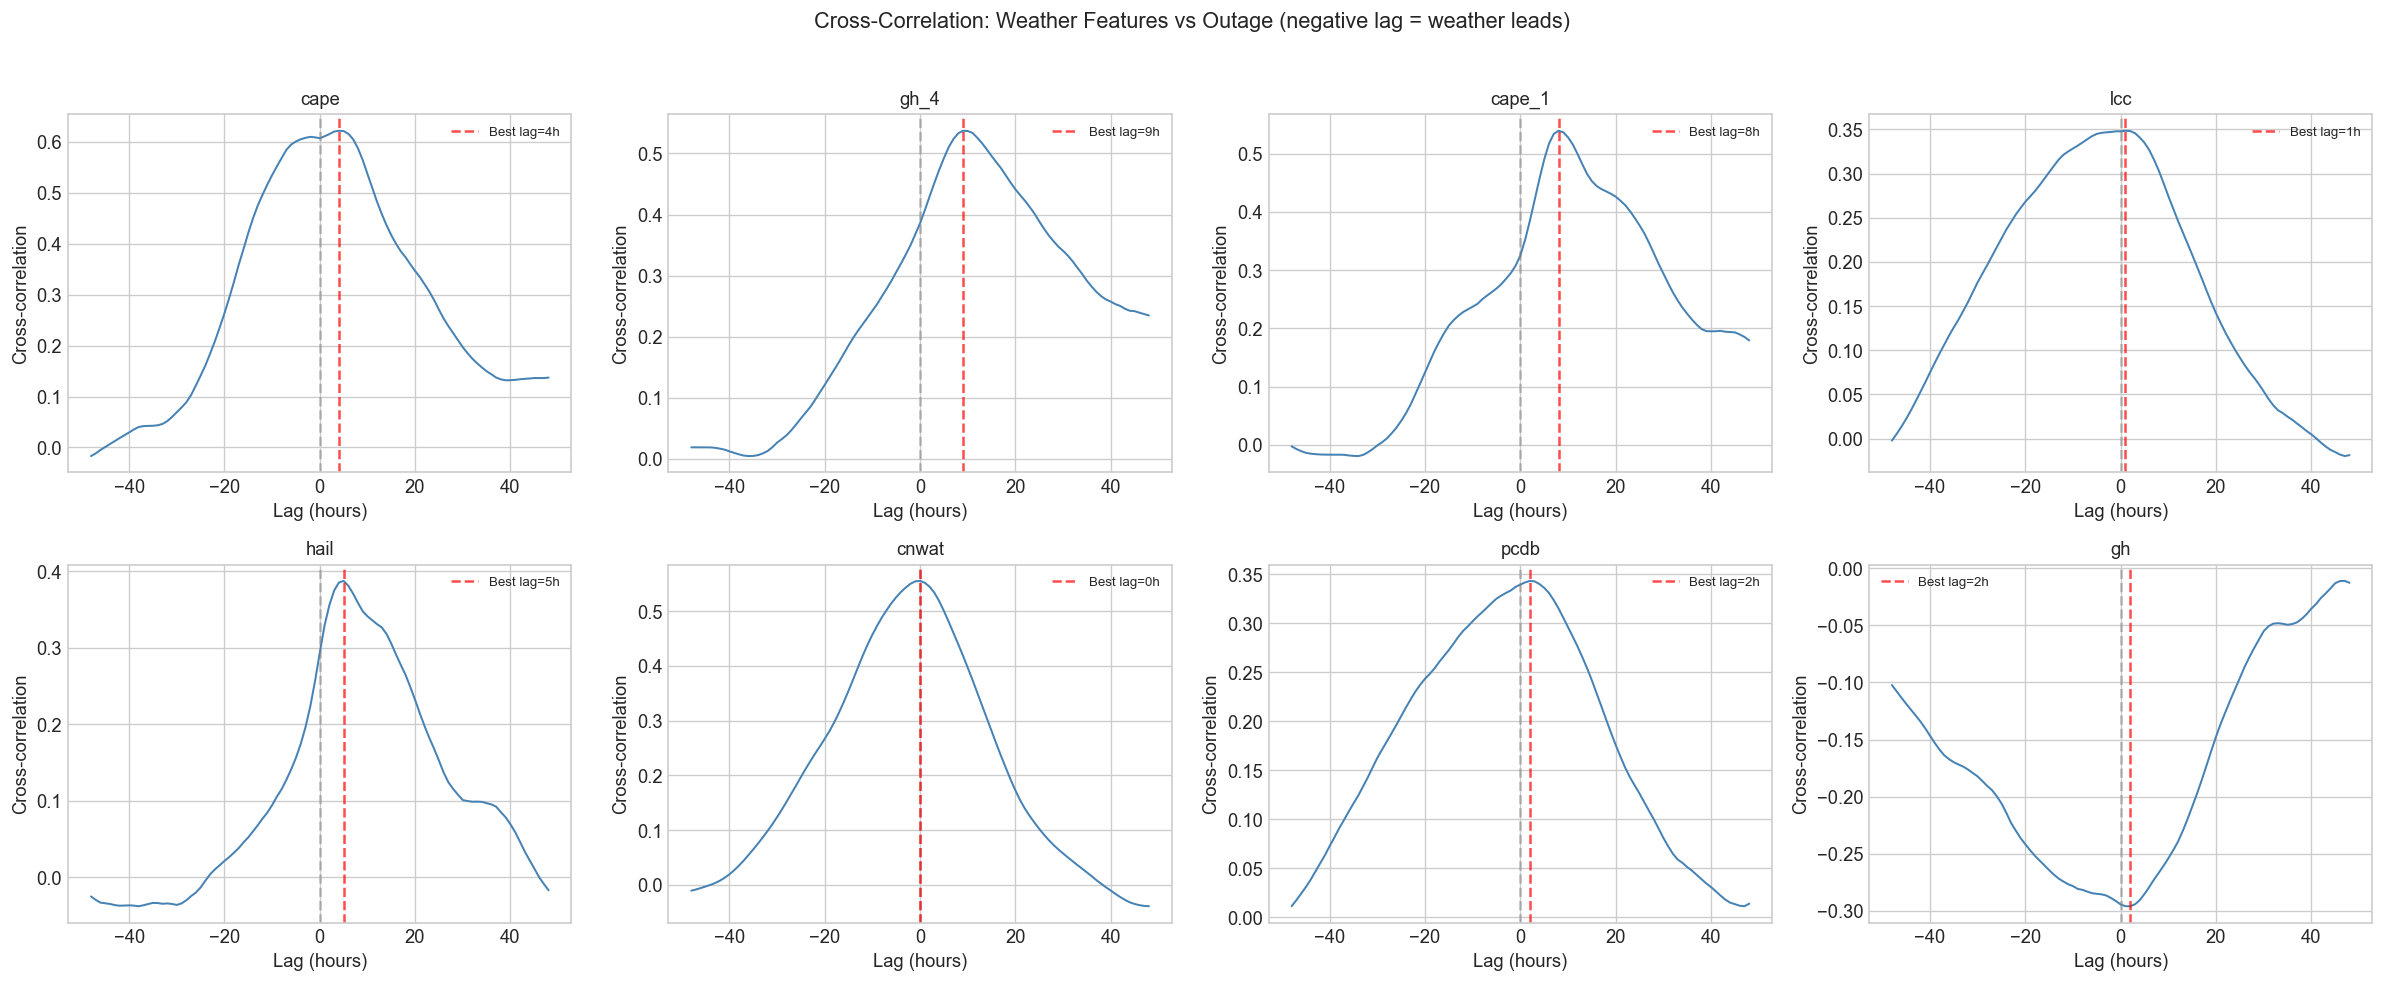


=== Best Lag Summary ===
(Negative = weather change leads outage; Positive = outage leads weather recovery)
Feature      Best Lag (h)   Cross-Corr
--------------------------------------
cape                   +4      +0.6216
gh_4                   +9      +0.5372
cape_1                 +8      +0.5394
lcc                    +1      +0.3485
hail                   +5      +0.3873
cnwat                  +0      +0.5558
pcdb                   +2      +0.3432
gh                     +2      -0.2960


In [20]:
# 8.1 Cross-correlation analysis
total_outage = np.nansum(out, axis=1)  # (T,)

key_features = [x[0] for x in corr_with_outage[:8]]
max_lag = 48  # check \u00b148 hours

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

lag_results = []

for i, f_name in enumerate(key_features):
    f_idx = features.index(f_name)
    weather_avg = np.nanmean(weather[:, :, f_idx], axis=1)  # (T,) county average
    
    # Drop NaN
    valid = ~(np.isnan(weather_avg) | np.isnan(total_outage))
    w_clean = weather_avg[valid]
    o_clean = total_outage[valid]
    
    # Normalize
    w_norm = (w_clean - np.mean(w_clean)) / (np.std(w_clean) + 1e-8)
    o_norm = (o_clean - np.mean(o_clean)) / (np.std(o_clean) + 1e-8)
    
    # Compute cross-correlation
    lags = range(-max_lag, max_lag + 1)
    cross_corr = []
    for lag in lags:
        if lag >= 0:
            cc = np.mean(w_norm[:len(w_norm)-lag] * o_norm[lag:])
        else:
            cc = np.mean(w_norm[-lag:] * o_norm[:len(o_norm)+lag])
        cross_corr.append(cc)
    
    cross_corr = np.array(cross_corr)
    best_lag = list(lags)[np.argmax(np.abs(cross_corr))]
    best_cc = cross_corr[np.argmax(np.abs(cross_corr))]
    lag_results.append((f_name, best_lag, best_cc))
    
    axes[i].plot(list(lags), cross_corr, color='steelblue', linewidth=1.2)
    axes[i].axvline(0, color='gray', linestyle='--', alpha=0.5)
    axes[i].axvline(best_lag, color='red', linestyle='--', alpha=0.7,
                    label=f'Best lag={best_lag}h')
    axes[i].set_title(f_name, fontsize=11)
    axes[i].set_xlabel('Lag (hours)')
    axes[i].set_ylabel('Cross-correlation')
    axes[i].legend(fontsize=8)

plt.suptitle('Cross-Correlation: Weather Features vs Outage (negative lag = weather leads)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Best Lag Summary ===')
print('(Negative = weather change leads outage; Positive = outage leads weather recovery)')
print(f'{"Feature":<12} {"Best Lag (h)":>12} {"Cross-Corr":>12}')
print('-' * 38)
for name, lag, cc in lag_results:
    print(f'{name:<12} {lag:>+12d} {cc:>+12.4f}')

## 9. Data Quality Check

In [21]:
# 9.1 NaN ratio per variable
print('=== NaN Ratio Check ===')
print(f'out:     {np.isnan(out).mean()*100:.2f}%')
print(f'tracked: {np.isnan(tracked).mean()*100:.2f}%')
print()

nan_per_feature = []
for f_idx, f_name in enumerate(features):
    nan_ratio = np.isnan(weather[:, :, f_idx]).mean()
    nan_per_feature.append((f_name, nan_ratio))

nan_per_feature.sort(key=lambda x: -x[1])

print('Weather feature NaN ratios (top 20):')
print(f'{"Feature":<12} {"NaN %":>8}')
print('-' * 22)
for name, ratio in nan_per_feature[:20]:
    print(f'{name:<12} {ratio*100:>7.2f}%')

high_nan = [name for name, ratio in nan_per_feature if ratio > 0.3]
if high_nan:
    print(f'\nFeatures with >30% NaN ({len(high_nan)}): {high_nan}')
    print('Recommendation: consider dropping these or using specialized imputation.')
else:
    print('\nAll features have NaN ratio below 30%.')

=== NaN Ratio Check ===
out:     0.00%
tracked: 0.00%

Weather feature NaN ratios (top 20):
Feature         NaN %
----------------------
SBT113          0.00%
SBT114          0.00%
SBT123          0.00%
SBT124          0.00%
aod             0.00%
bgrun           0.00%
blh             0.00%
cape            0.00%
cape_1          0.00%
cfnsf           0.00%
cfrzr           0.00%
cicep           0.00%
cin             0.00%
cnwat           0.00%
cpofp           0.00%
crain           0.00%
csnow           0.00%
d2m             0.00%
fricv           0.00%
frzr            0.00%

All features have NaN ratio below 30%.


In [22]:
# 9.2 Constant/near-constant feature check
low_var_features = []
for f_idx, f_name in enumerate(features):
    col = weather[:, :, f_idx].flatten()
    col_clean = col[~np.isnan(col)]
    if len(col_clean) > 0:
        cv = np.std(col_clean) / (abs(np.mean(col_clean)) + 1e-10)  # coefficient of variation
        if cv < 0.01:
            low_var_features.append((f_name, np.mean(col_clean), np.std(col_clean), cv))

if low_var_features:
    print(f'Near-constant features (CV < 0.01): {len(low_var_features)}')
    for name, mean, std, cv in low_var_features:
        print(f'  {name}: mean={mean:.4f}, std={std:.6f}, CV={cv:.6f}')
    print('\nThese features carry almost no information — safe to drop during modeling.')
else:
    print('No near-constant features found.')

Near-constant features (CV < 0.01): 17
  aod: mean=0.0000, std=0.000000, CV=0.000000
  bgrun: mean=0.0000, std=0.000000, CV=0.000000
  cfrzr: mean=0.0000, std=0.000000, CV=0.000000
  cicep: mean=0.0000, std=0.000000, CV=0.000000
  crain: mean=0.0000, std=0.000000, CV=0.000000
  csnow: mean=0.0000, std=0.000000, CV=0.000000
  hail_2: mean=0.0000, std=0.000000, CV=0.000000
  ltng: mean=0.0000, std=0.000000, CV=0.000000
  prate: mean=0.0000, std=0.000000, CV=0.000000
  sdwe_1: mean=0.0000, std=0.000000, CV=0.000000
  siconc: mean=0.0000, std=0.000000, CV=0.000000
  ssrun: mean=0.0000, std=0.000000, CV=0.000000
  tcoli: mean=0.0000, std=0.000000, CV=0.000000
  tcolw: mean=0.0000, std=0.000000, CV=0.000000
  tp: mean=0.0000, std=0.000000, CV=0.000000
  unknown_7: mean=0.0000, std=0.000000, CV=0.000000
  unknown_9: mean=0.0000, std=0.000000, CV=0.000000

These features carry almost no information — safe to drop during modeling.


## 10. Modeling Recommendations Summary

1. Target Variable:
   - Data is extremely right-skewed -> use log(1+x) transform
   - Or use Huber Loss as loss function
   - Consider predicting out/tracked (ratio) instead of raw count

2. Temporal Features:
   - Add hour_of_day (if diurnal pattern exists)
   - Add day_of_week (if weekday pattern exists)
   - Add rolling statistics of past outages (6h/12h/24h mean, max)

3. Weather Feature Selection:
   - Use top 20-30 features from the correlation ranking
   - Drop high-NaN and near-constant features
   - Merge highly redundant pairs (|r|>0.9, keep one)
   - Or use PCA to reduce to 20-30 components

4. Feature Engineering:
   - Lagged values of key weather features (based on cross-correlation)
   - Rolling statistics of weather (e.g., 6h cumulative precipitation, max wind)
   - Weather change indicators (current value - value 6h ago)

5. Spatial Modeling:
   - If inter-county correlation is high -> consider GNN or neighbor features
   - If weak -> independent per-county models are fine

6. Lookback Window:
   - Set based on cross-correlation lag analysis results
   - Demo uses 24h; experiment with 48h or longer